# HRP2/HRP3 Gene detection 



In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.size"] = 12
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["legend.frameon"] = False

ROOT = Path("/mnt/hpc_acegid/home/khadmig/work/data/malaria/ILLUMINA_DATA/260420_VH00635_5_AAHL3MNM5/results")

OUTDIR = ROOT / "Figures_tables"
OUTDIR.mkdir(parents=True, exist_ok=True)

gene_calls_path = ROOT / "cohort/coverage/all_samples.gene_calls.tsv"
gene_prev_path = ROOT / "cohort/coverage/gene_prevalence.tsv"
haps_path = ROOT / "cohort/haplotypes/all_samples.haplotypes.tsv"
hap_prev_path = ROOT / "cohort/haplotypes/haplotype_prevalence.tsv"
qc_path = ROOT / "cohort/qc/all_samples.qc_summary.tsv"
var_path = ROOT / "cohort/variants/all_samples.hrp2_hrp3.variants.tsv"

gene_calls = pd.read_csv(gene_calls_path, sep="\t")
gene_prev = pd.read_csv(gene_prev_path, sep="\t")
haps = pd.read_csv(haps_path, sep="\t")
hap_prev = pd.read_csv(hap_prev_path, sep="\t")
qc = pd.read_csv(qc_path, sep="\t")
variants = pd.read_csv(var_path, sep="\t")

def clean_gene(g):
    g = str(g)
    if "HRP2" in g:
        return "HRP2"
    if "HRP3" in g:
        return "HRP3"
    return g

def sample_ok(s):
    return "Undetermined" not in str(s)

gene_calls = gene_calls[gene_calls["sample"].map(sample_ok)].copy()
haps = haps[haps["sample"].map(sample_ok)].copy()
qc = qc[qc["sample"].map(sample_ok)].copy()
variants = variants[variants["sample"].map(sample_ok)].copy()

gene_calls["gene_label"] = gene_calls["gene"].map(clean_gene)
gene_prev["gene_label"] = gene_prev["gene"].map(clean_gene)
haps["gene_label"] = haps["gene"].map(clean_gene)
hap_prev["gene_label"] = hap_prev["gene"].map(clean_gene)
variants["gene_label"] = variants["gene"].map(clean_gene)

gene_order = ["HRP2", "HRP3"]
sample_order = sorted(qc["sample"].unique().tolist())

gene_calls["gene_label"] = pd.Categorical(gene_calls["gene_label"], categories=gene_order, ordered=True)
gene_prev["gene_label"] = pd.Categorical(gene_prev["gene_label"], categories=gene_order, ordered=True)
haps["gene_label"] = pd.Categorical(haps["gene_label"], categories=gene_order, ordered=True)
hap_prev["gene_label"] = pd.Categorical(hap_prev["gene_label"], categories=gene_order, ordered=True)
variants["gene_label"] = pd.Categorical(variants["gene_label"], categories=gene_order, ordered=True)

present_color = "#1f77b4"
deleted_color = "#d62728"
hrp2_color = "#1f77b4"
hrp3_color = "#ff7f0e"

def stylize(ax, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontweight="bold")
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontweight="bold")
    if title is not None:
        ax.set_title(title, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=11, width=1.2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
    return ax

def savefig(name):
    for ext in ["png", "pdf" , "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}",dpi = 600 ,bbox_inches="tight")


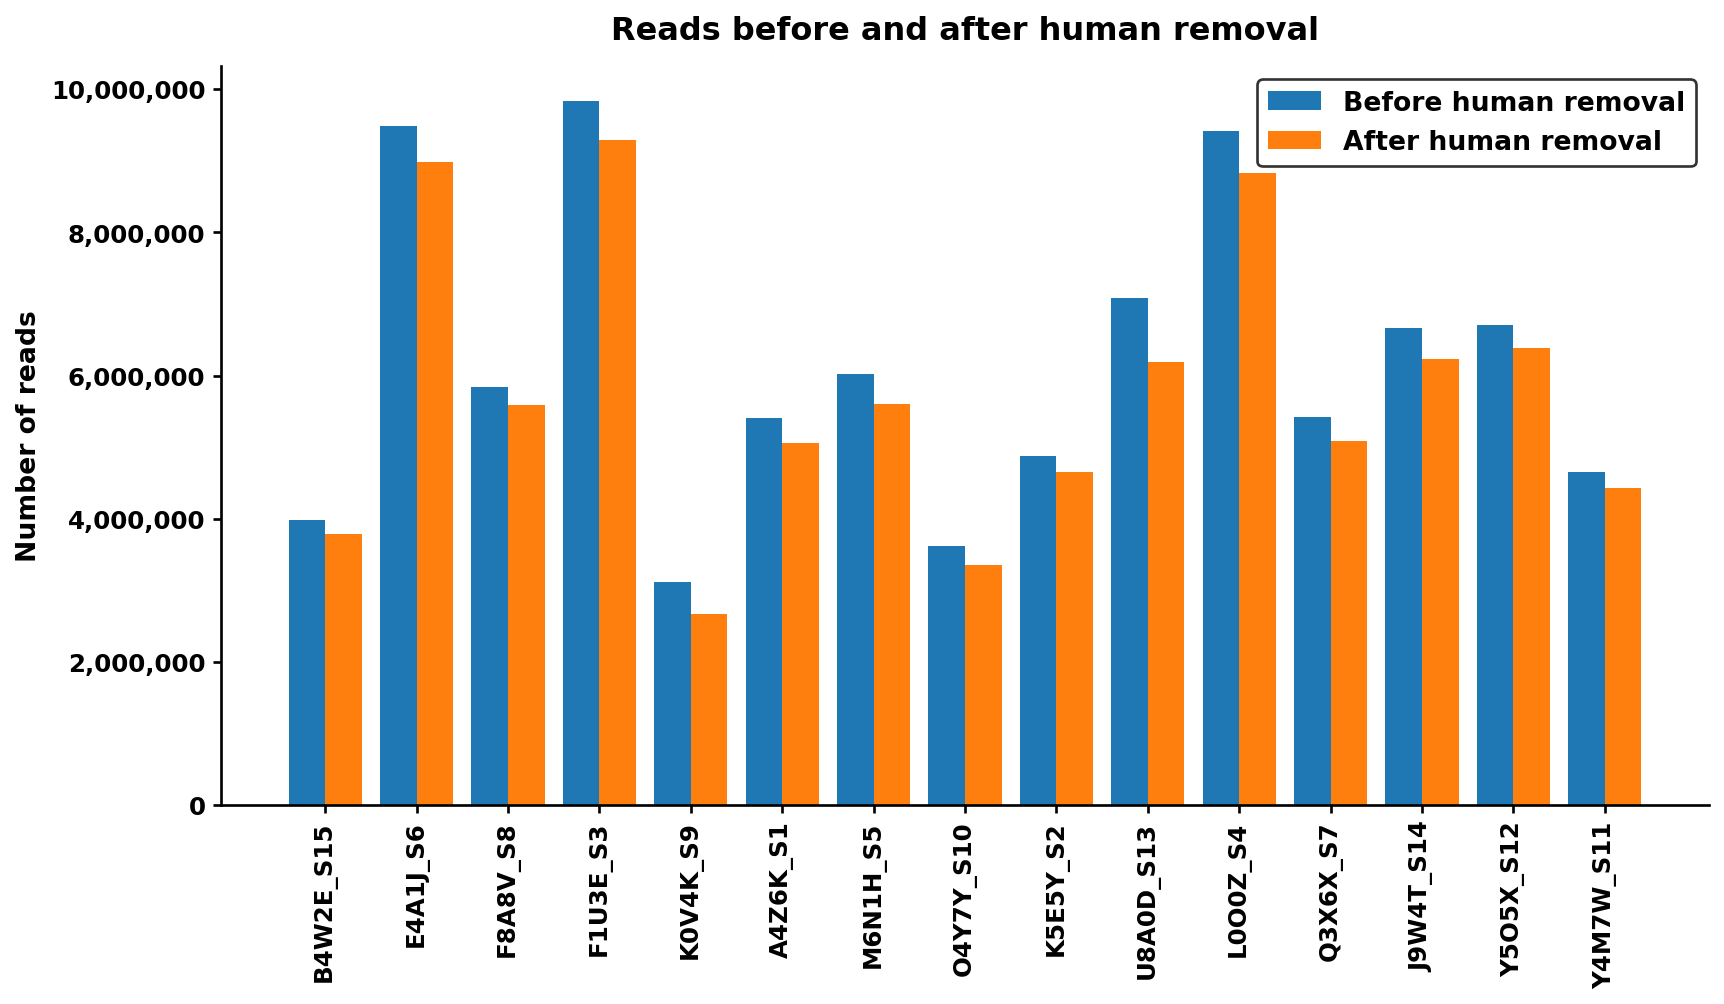

In [17]:
import matplotlib.ticker as mticker

reads_before = qc.set_index("sample")["raw_total_reads"]
reads_after = qc.set_index("sample")["clean_total_reads"]

df_reads = pd.DataFrame({
    "Before human removal": reads_before,
    "After human removal": reads_after
}).reset_index()

x = np.arange(len(df_reads))
width = 0.4

def stylize(ax, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontweight="bold")
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontweight="bold")
    if title is not None:
        ax.set_title(title, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=11, width=1.2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
    return ax

def savefig(name):
    for ext in ["png", "pdf", "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, df_reads["Before human removal"], width=width, label="Before human removal")
ax.bar(x + width/2, df_reads["After human removal"], width=width, label="After human removal")

ax.set_xticks(x)
ax.set_xticklabels(df_reads["sample"], rotation=90)

ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

stylize(ax, ylabel="Number of reads", title="Reads before and after human removal")

legend = ax.legend(frameon=True)
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

savefig("reads_before_after_human_removal")
plt.show()

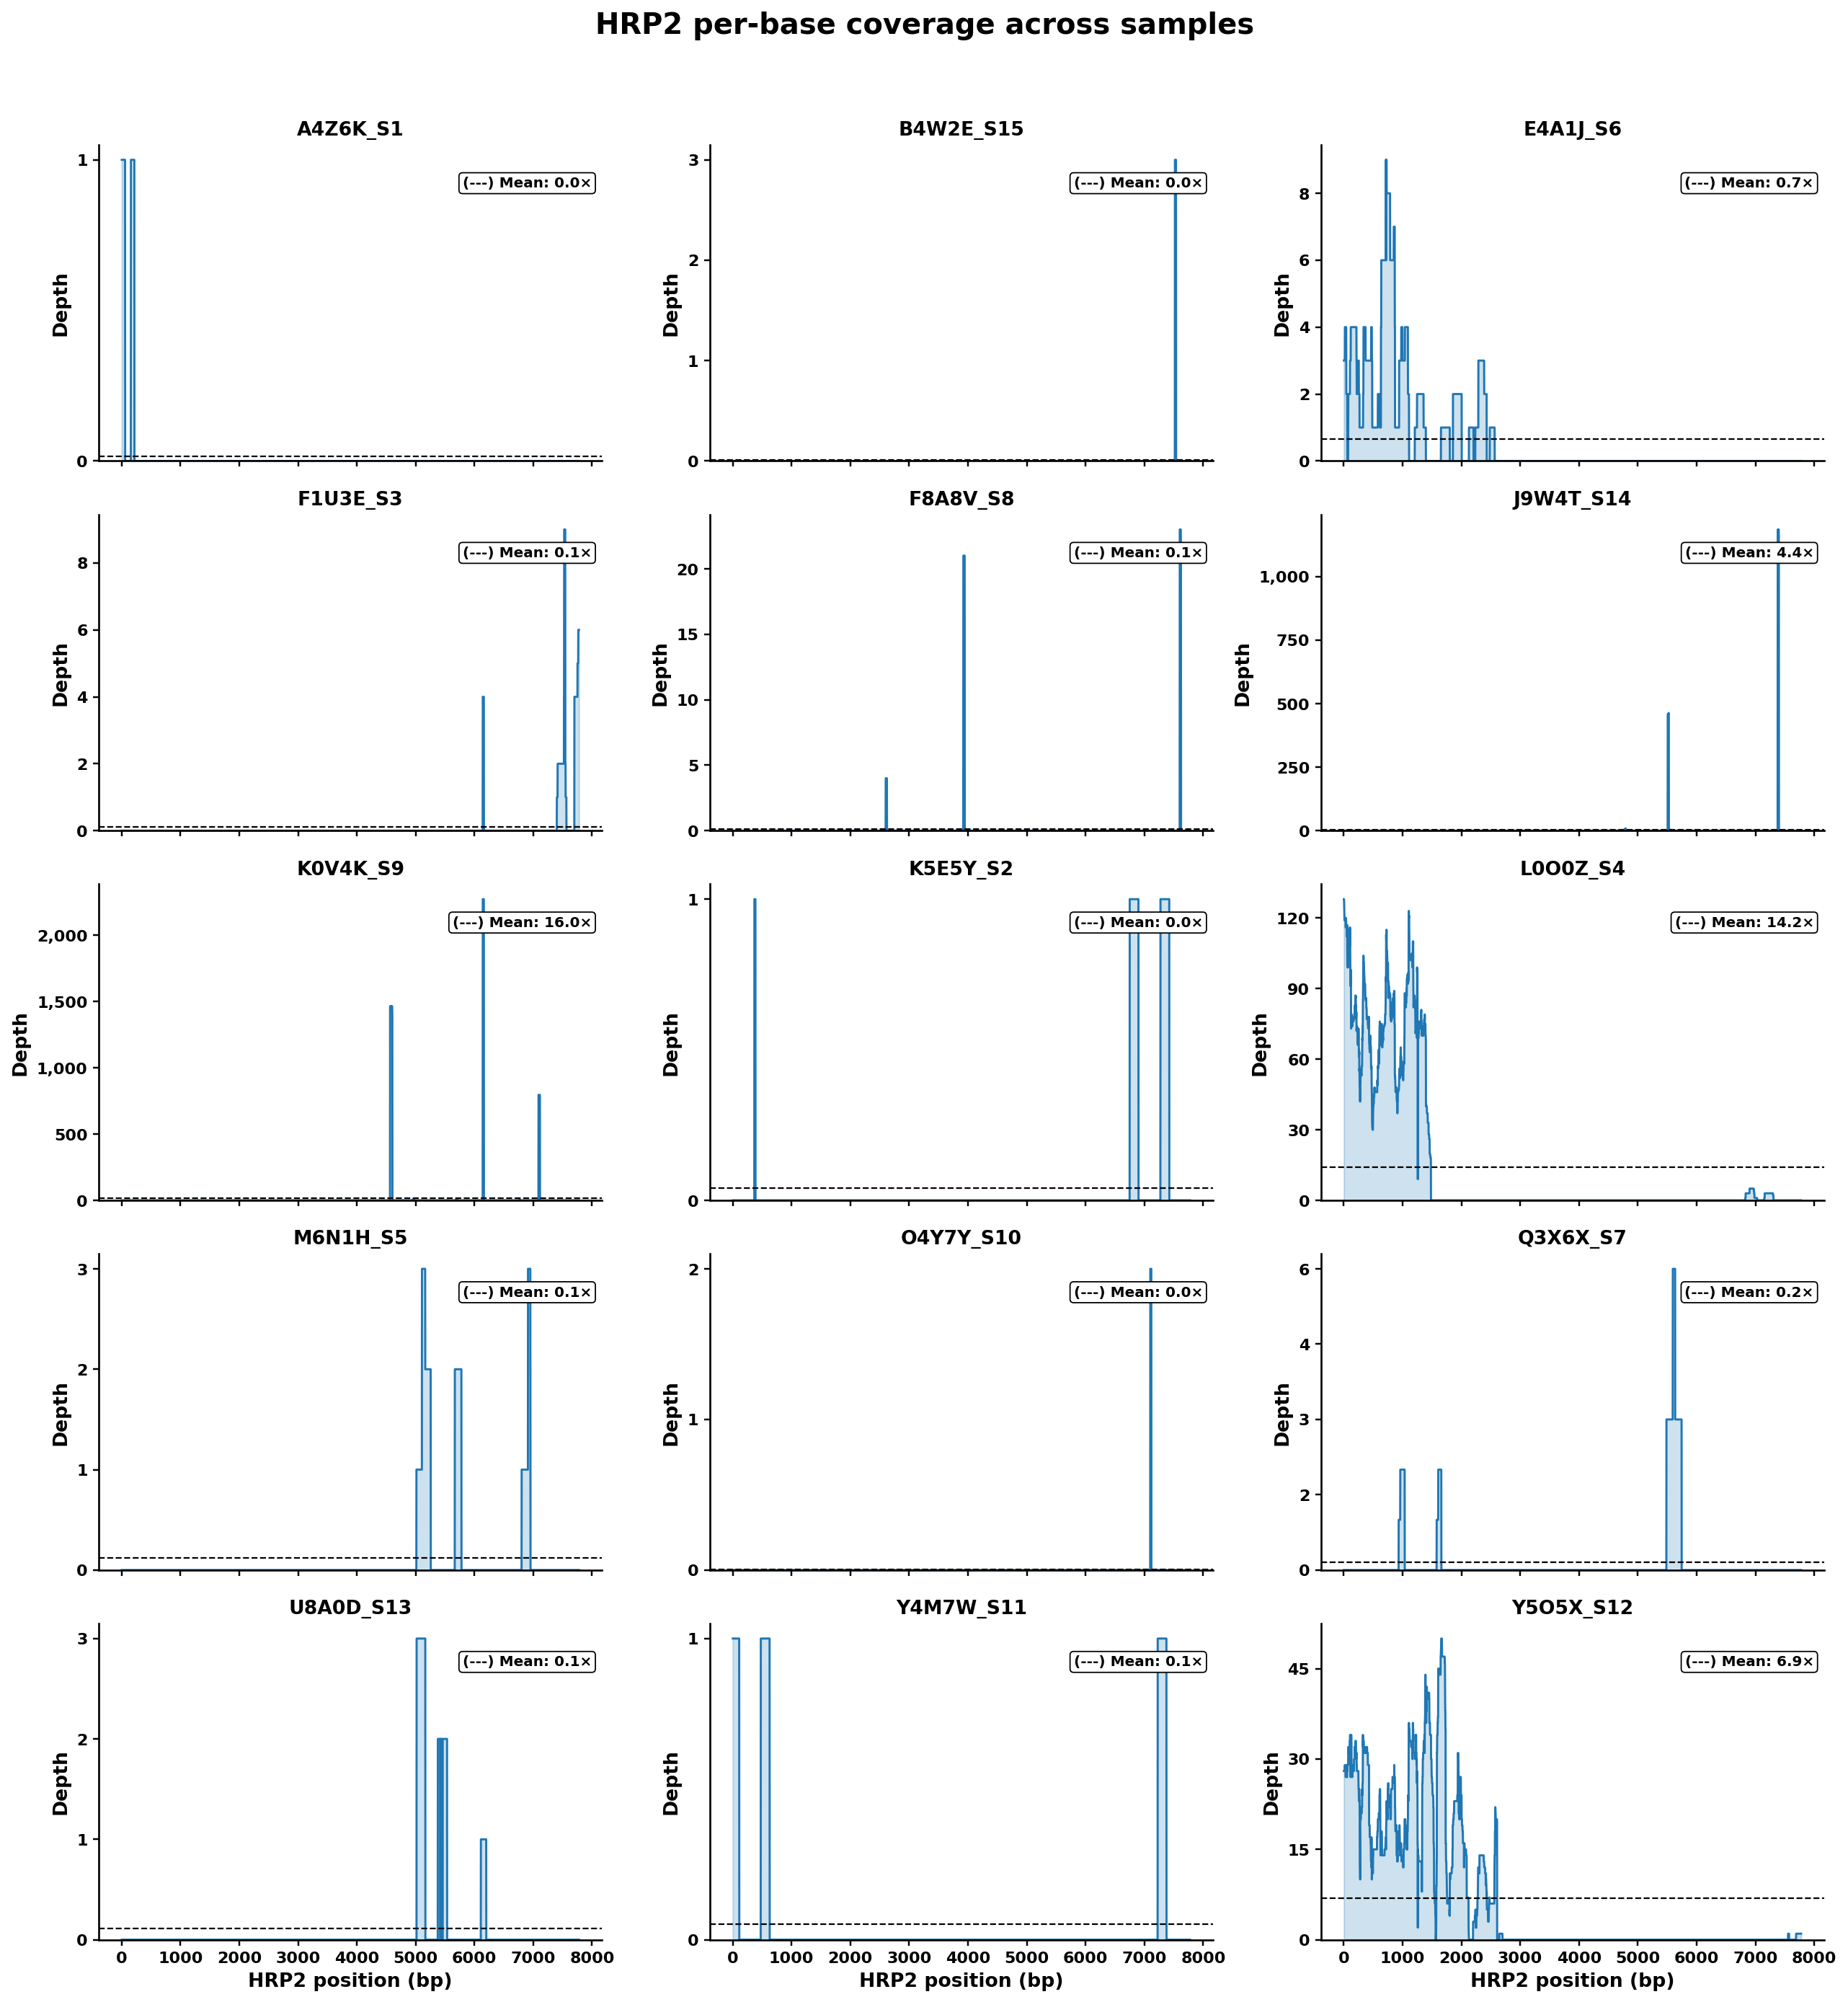

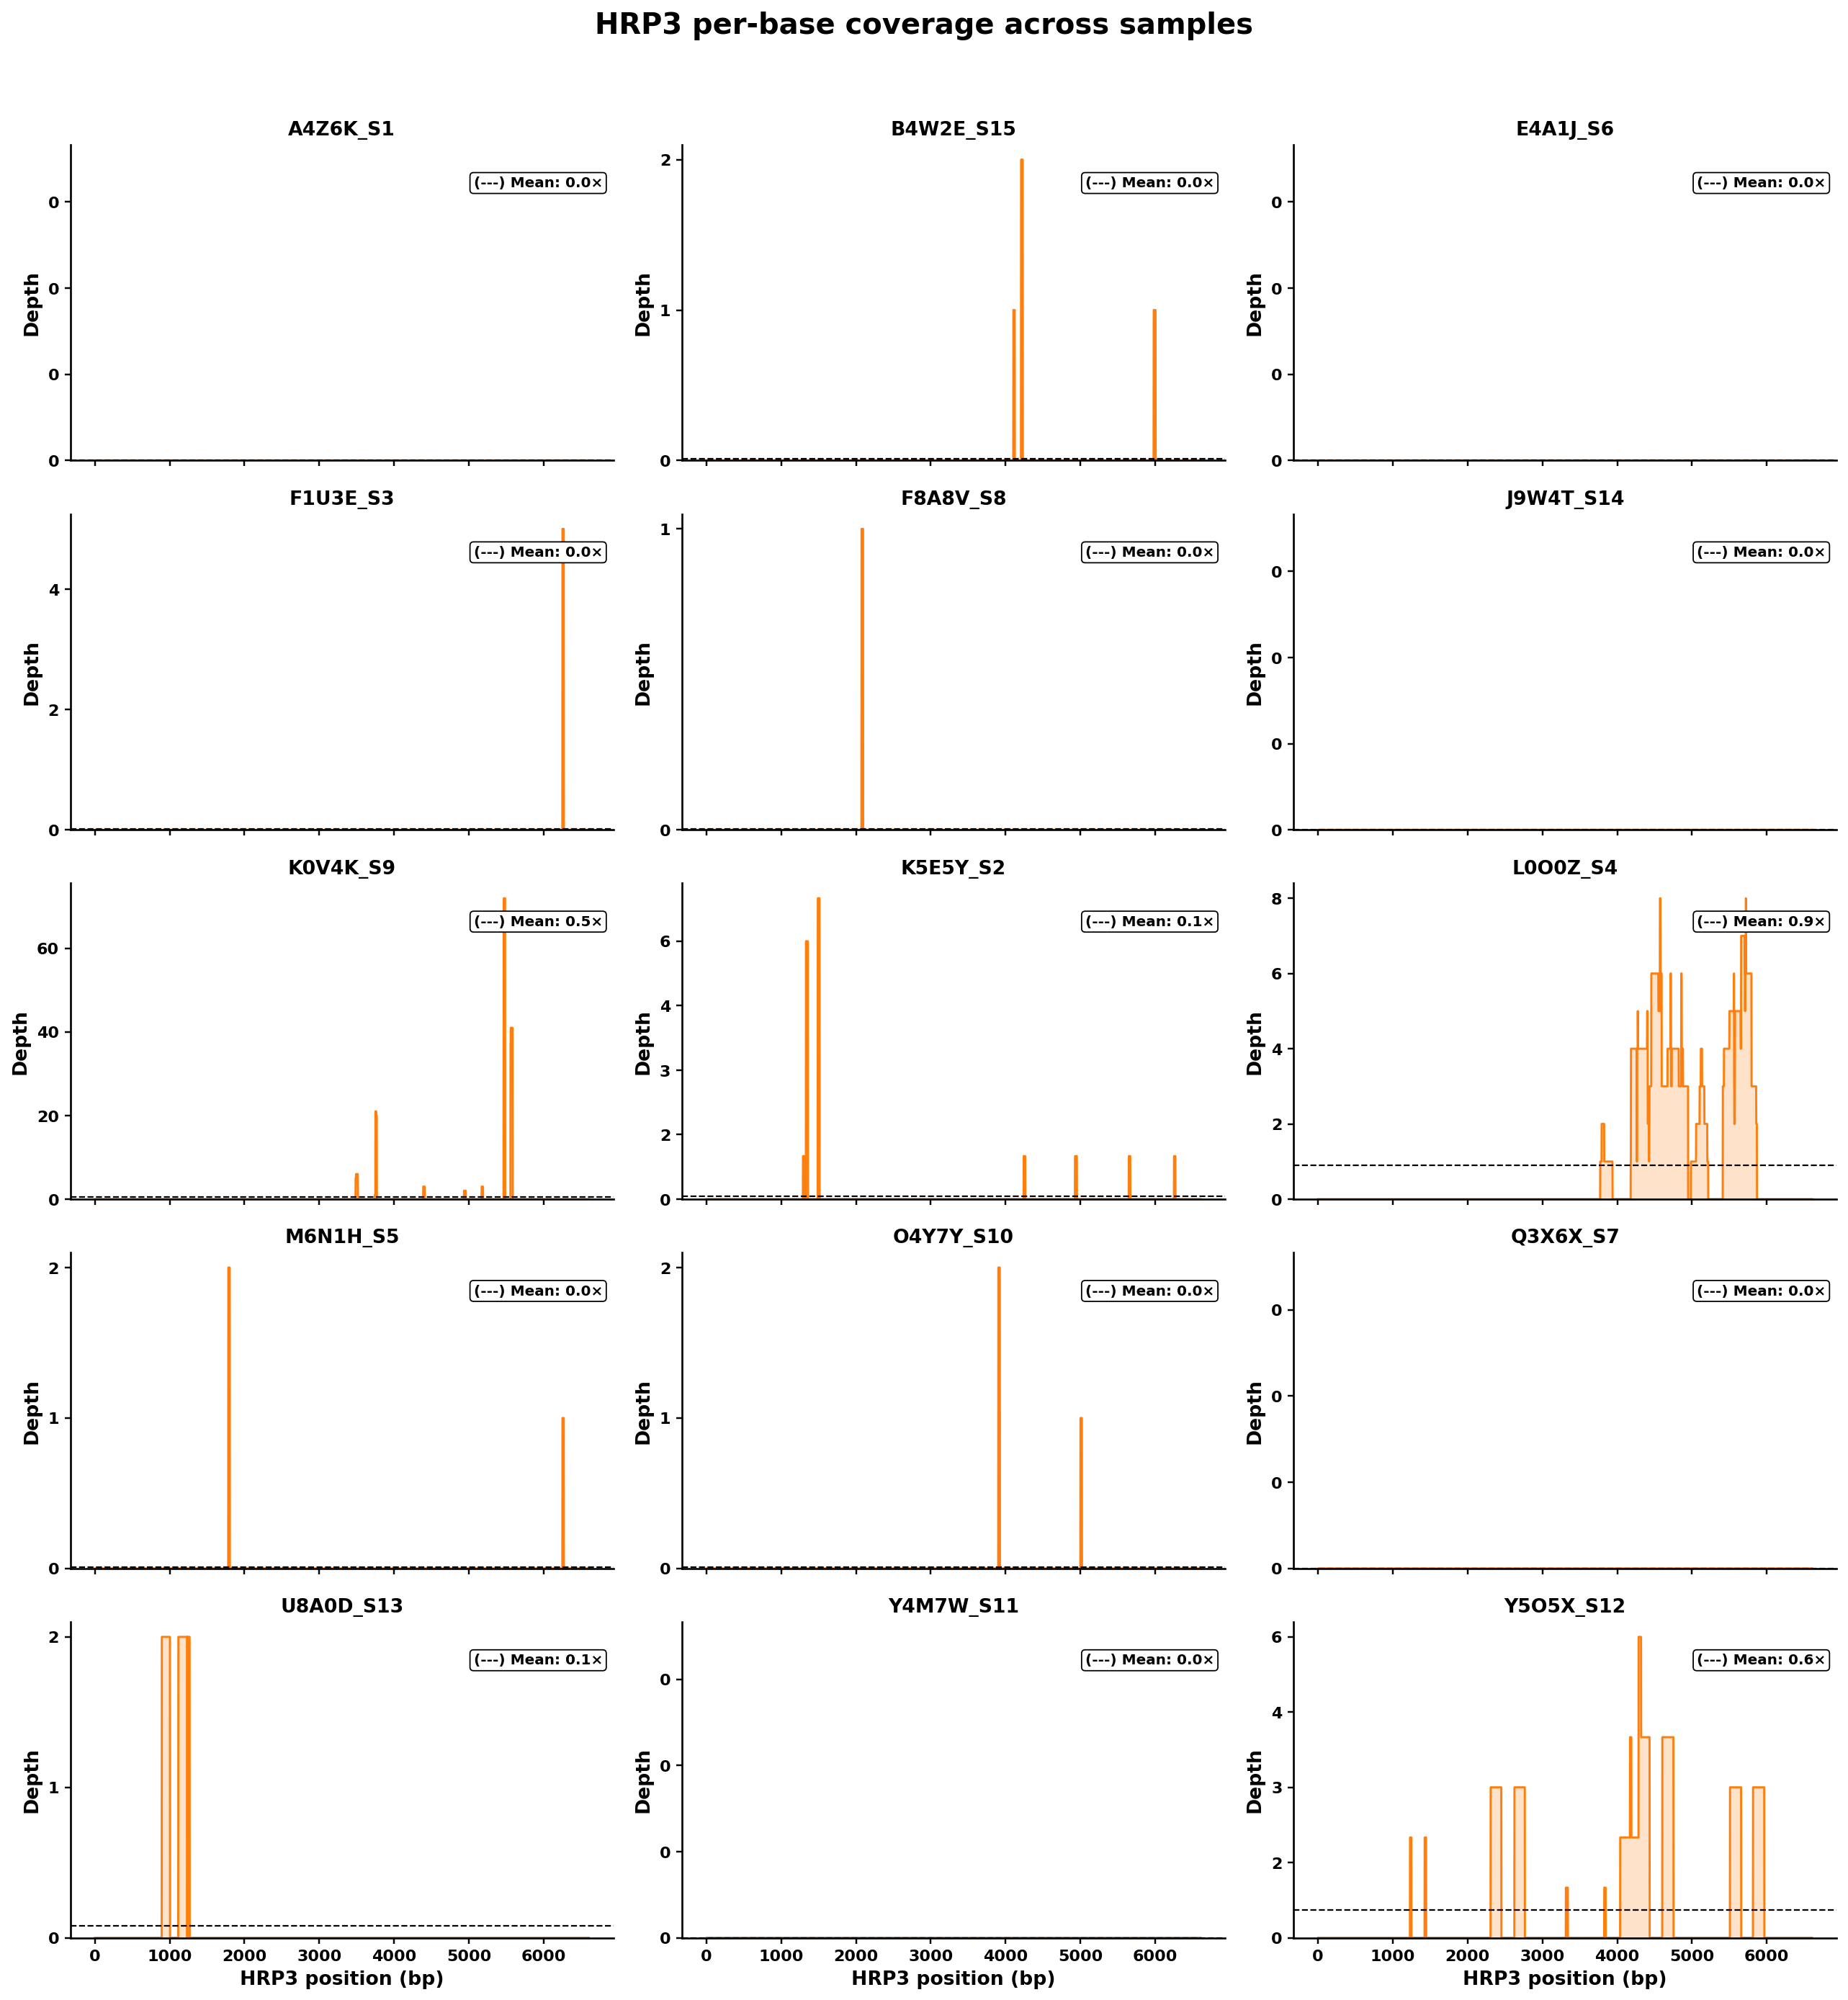

In [21]:
import math
import matplotlib.ticker as mticker

DEPTH_FILES = sorted(ROOT.glob("samples/*/coverage/*.gene_depth.tsv"))

genes = {
    "HRP2": {
        "chrom": "Pf3D7_08_v3",
        "start": 1371212,
        "end": 1378988,
        "color": "#1f77b4"
    },
    "HRP3": {
        "chrom": "Pf3D7_13_v3",
        "start": 2838236,
        "end": 2844840,
        "color": "#ff7f0e"
    }
}

def read_depth_file(path):
    sample = path.parent.parent.name
    df = pd.read_csv(path, sep="\t", header=None, names=["chrom", "pos", "depth"])
    df["sample"] = sample
    return df

depth = pd.concat([read_depth_file(p) for p in DEPTH_FILES], ignore_index=True)
depth = depth[~depth["sample"].str.contains("Undetermined", na=False)].copy()

def savefig(name):
    for ext in ["png", "pdf", "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")

def plot_gene_depth_panels(gene_name):
    info = genes[gene_name]

    sub = depth[
        (depth["chrom"] == info["chrom"]) &
        (depth["pos"] >= info["start"]) &
        (depth["pos"] <= info["end"])
    ].copy()

    sub["relative_position"] = sub["pos"] - info["start"] + 1

    samples = sorted(sub["sample"].unique())
    n_samples = len(samples)

    ncols = 3
    nrows = math.ceil(n_samples / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.4 * ncols, 3.4 * nrows),
        sharex=True,
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        sdf = sub[sub["sample"] == sample].sort_values("relative_position")

        ax.plot(
            sdf["relative_position"],
            sdf["depth"],
            color=info["color"],
            linewidth=1.3
        )

        ax.fill_between(
            sdf["relative_position"],
            sdf["depth"],
            color=info["color"],
            alpha=0.22
        )

        mean_depth = sdf["depth"].mean()
        max_depth = sdf["depth"].max()

        ax.axhline(mean_depth, color="black", linestyle="--", linewidth=1.0)

        if max_depth <= 5:
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
        else:
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
        ax.set_ylim(bottom=0)

        ax.set_title(sample, fontweight="bold", fontsize=12)
        ax.set_ylabel("Depth", fontweight="bold")

        ax.tick_params(axis="both", labelsize=10, width=1.1)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.text(
            0.98,
            0.90,
            f"(---) Mean: {mean_depth:.1f}×",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
                boxstyle="round,pad=0.25"
            )
        )

    for ax in axes[n_samples:]:
        ax.axis("off")

    for ax in axes[-ncols:]:
        ax.set_xlabel(f"{gene_name} position (bp)", fontweight="bold")

    fig.suptitle(
        f"{gene_name} per-base coverage across samples",
        fontsize=18,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    savefig(f"{gene_name.lower()}_per_sample_coverage_panels")
    plt.show()

plot_gene_depth_panels("HRP2")
plot_gene_depth_panels("HRP3")

In [25]:
import gzip
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

VCF_FILES = sorted(ROOT.glob("samples/*/variants/*.raw.filtered.ann.vcf.gz"))

aa3_to_aa1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
    "Ter": "*"
}

target_genes = {
    "PF3D7_0831800": "HRP2",
    "PF3D7_1372200": "HRP3"
}

effect_colors = {
    "missense_variant": "#d62728",
    "synonymous_variant": "#2ca02c",
    "stop_gained": "#000000",
    "stop_lost": "#9467bd",
    "start_lost": "#8c564b",
    "frameshift_variant": "#ff7f0e",
    "inframe_insertion": "#17becf",
    "inframe_deletion": "#1f77b4",
    "protein_altering_variant": "#e377c2"
}

def convert_hgvsp(hgvsp):
    hgvsp = str(hgvsp).replace("p.", "")
    m = re.search(r"([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter|\*)", hgvsp)
    if not m:
        return None, None, None, None

    ref3, pos, alt3 = m.groups()
    ref1 = aa3_to_aa1.get(ref3)
    alt1 = "*" if alt3 == "*" else aa3_to_aa1.get(alt3)

    if ref1 is None or alt1 is None:
        return None, None, None, None

    return ref1, int(pos), alt1, f"{ref1}{pos}{alt1}"

rows = []

for vcf in VCF_FILES:
    sample = vcf.parts[-3]

    if "Undetermined" in sample:
        continue

    with gzip.open(vcf, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue

            fields = line.rstrip("\n").split("\t")

            if len(fields) < 8:
                continue

            chrom = fields[0]
            pos = int(fields[1])
            ref = fields[3]
            alt = fields[4]
            qual = fields[5]
            filt = fields[6]
            info = fields[7]

            ann_match = re.search(r"ANN=([^;]+)", info)

            if not ann_match:
                continue

            for ann in ann_match.group(1).split(","):
                a = ann.split("|")

                if len(a) < 11:
                    continue

                effect = a[1]
                impact = a[2]
                gene_id = a[4]
                hgvsp = a[10]

                if gene_id not in target_genes:
                    continue

                if not hgvsp.startswith("p."):
                    continue

                ref_aa, aa_pos, alt_aa, aa_mut = convert_hgvsp(hgvsp)

                if aa_mut is None:
                    continue

                rows.append({
                    "sample": sample,
                    "gene_id": gene_id,
                    "gene": target_genes[gene_id],
                    "chrom": chrom,
                    "genomic_position": pos,
                    "ref": ref,
                    "alt": alt,
                    "qual": qual,
                    "filter": filt,
                    "effect": effect,
                    "impact": impact,
                    "hgvsp": hgvsp,
                    "aa_ref": ref_aa,
                    "aa_position": aa_pos,
                    "aa_alt": alt_aa,
                    "aa_mutation": aa_mut
                })

aa_variants = pd.DataFrame(rows)

if not aa_variants.empty:
    aa_variants = aa_variants.drop_duplicates(
        subset=["sample", "gene", "aa_position", "aa_mutation", "effect"]
    ).sort_values(["gene", "sample", "aa_position"])

aa_variants_path = OUTDIR / "hrp2_hrp3_amino_acid_variants.tsv"
aa_variants.to_csv(aa_variants_path, sep="\t", index=False)

def savefig(name):
    for ext in ["png", "pdf", "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")

def plot_aa_mutation_panels(gene_name):
    if aa_variants.empty:
        print("No amino-acid mutations found")
        return

    sub = aa_variants[aa_variants["gene"] == gene_name].copy()

    if sub.empty:
        print(f"No amino-acid mutations found for {gene_name}")
        return

    samples = sorted(sub["sample"].unique())
    n_samples = len(samples)

    ncols = 3
    nrows = math.ceil(n_samples / ncols)

    xmax = int(sub["aa_position"].max()) + 5

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        sdf = sub[sub["sample"] == sample].copy()
        sdf = sdf.sort_values("aa_position")

        colors = [effect_colors.get(e, "#7f7f7f") for e in sdf["effect"]]

        ax.hlines(1, 1, xmax, color="black", linewidth=1.3)
        ax.vlines(sdf["aa_position"], 1, 1.35, color=colors, linewidth=2.0)
        ax.scatter(
            sdf["aa_position"],
            np.repeat(1.35, len(sdf)),
            c=colors,
            s=80,
            edgecolor="black",
            linewidth=0.8,
            zorder=3
        )

        for _, r in sdf.iterrows():
            ax.text(
                r["aa_position"],
                1.43,
                r["aa_mutation"],
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=8,
                fontweight="bold"
            )

        ax.set_title(sample, fontweight="bold", fontsize=12)
        ax.set_ylim(0.85, 1.78)
        ax.set_xlim(1, xmax)
        ax.set_yticks([])
        ax.set_xlabel("Protein position", fontweight="bold")

        ax.tick_params(axis="x", labelsize=10, width=1.1)

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

    for ax in axes[n_samples:]:
        ax.axis("off")

    used_effects = sorted(sub["effect"].unique())

    legend_handles = [
        Patch(
            facecolor=effect_colors.get(e, "#7f7f7f"),
            edgecolor="black",
            label=e.replace("_", " ")
        )
        for e in used_effects
    ]

    legend = fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=min(4, len(legend_handles)),
        frameon=True,
        fontsize=11
    )

    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.2)

    fig.suptitle(
        f"{gene_name} amino-acid mutations across samples",
        fontsize=18,
        fontweight="bold",
        y=1.10
    )

    plt.tight_layout()
    savefig(f"{gene_name.lower()}_amino_acid_mutation_panels")
    plt.show()

plot_aa_mutation_panels("HRP2")
plot_aa_mutation_panels("HRP3")

aa_variants

No amino-acid mutations found
No amino-acid mutations found


""


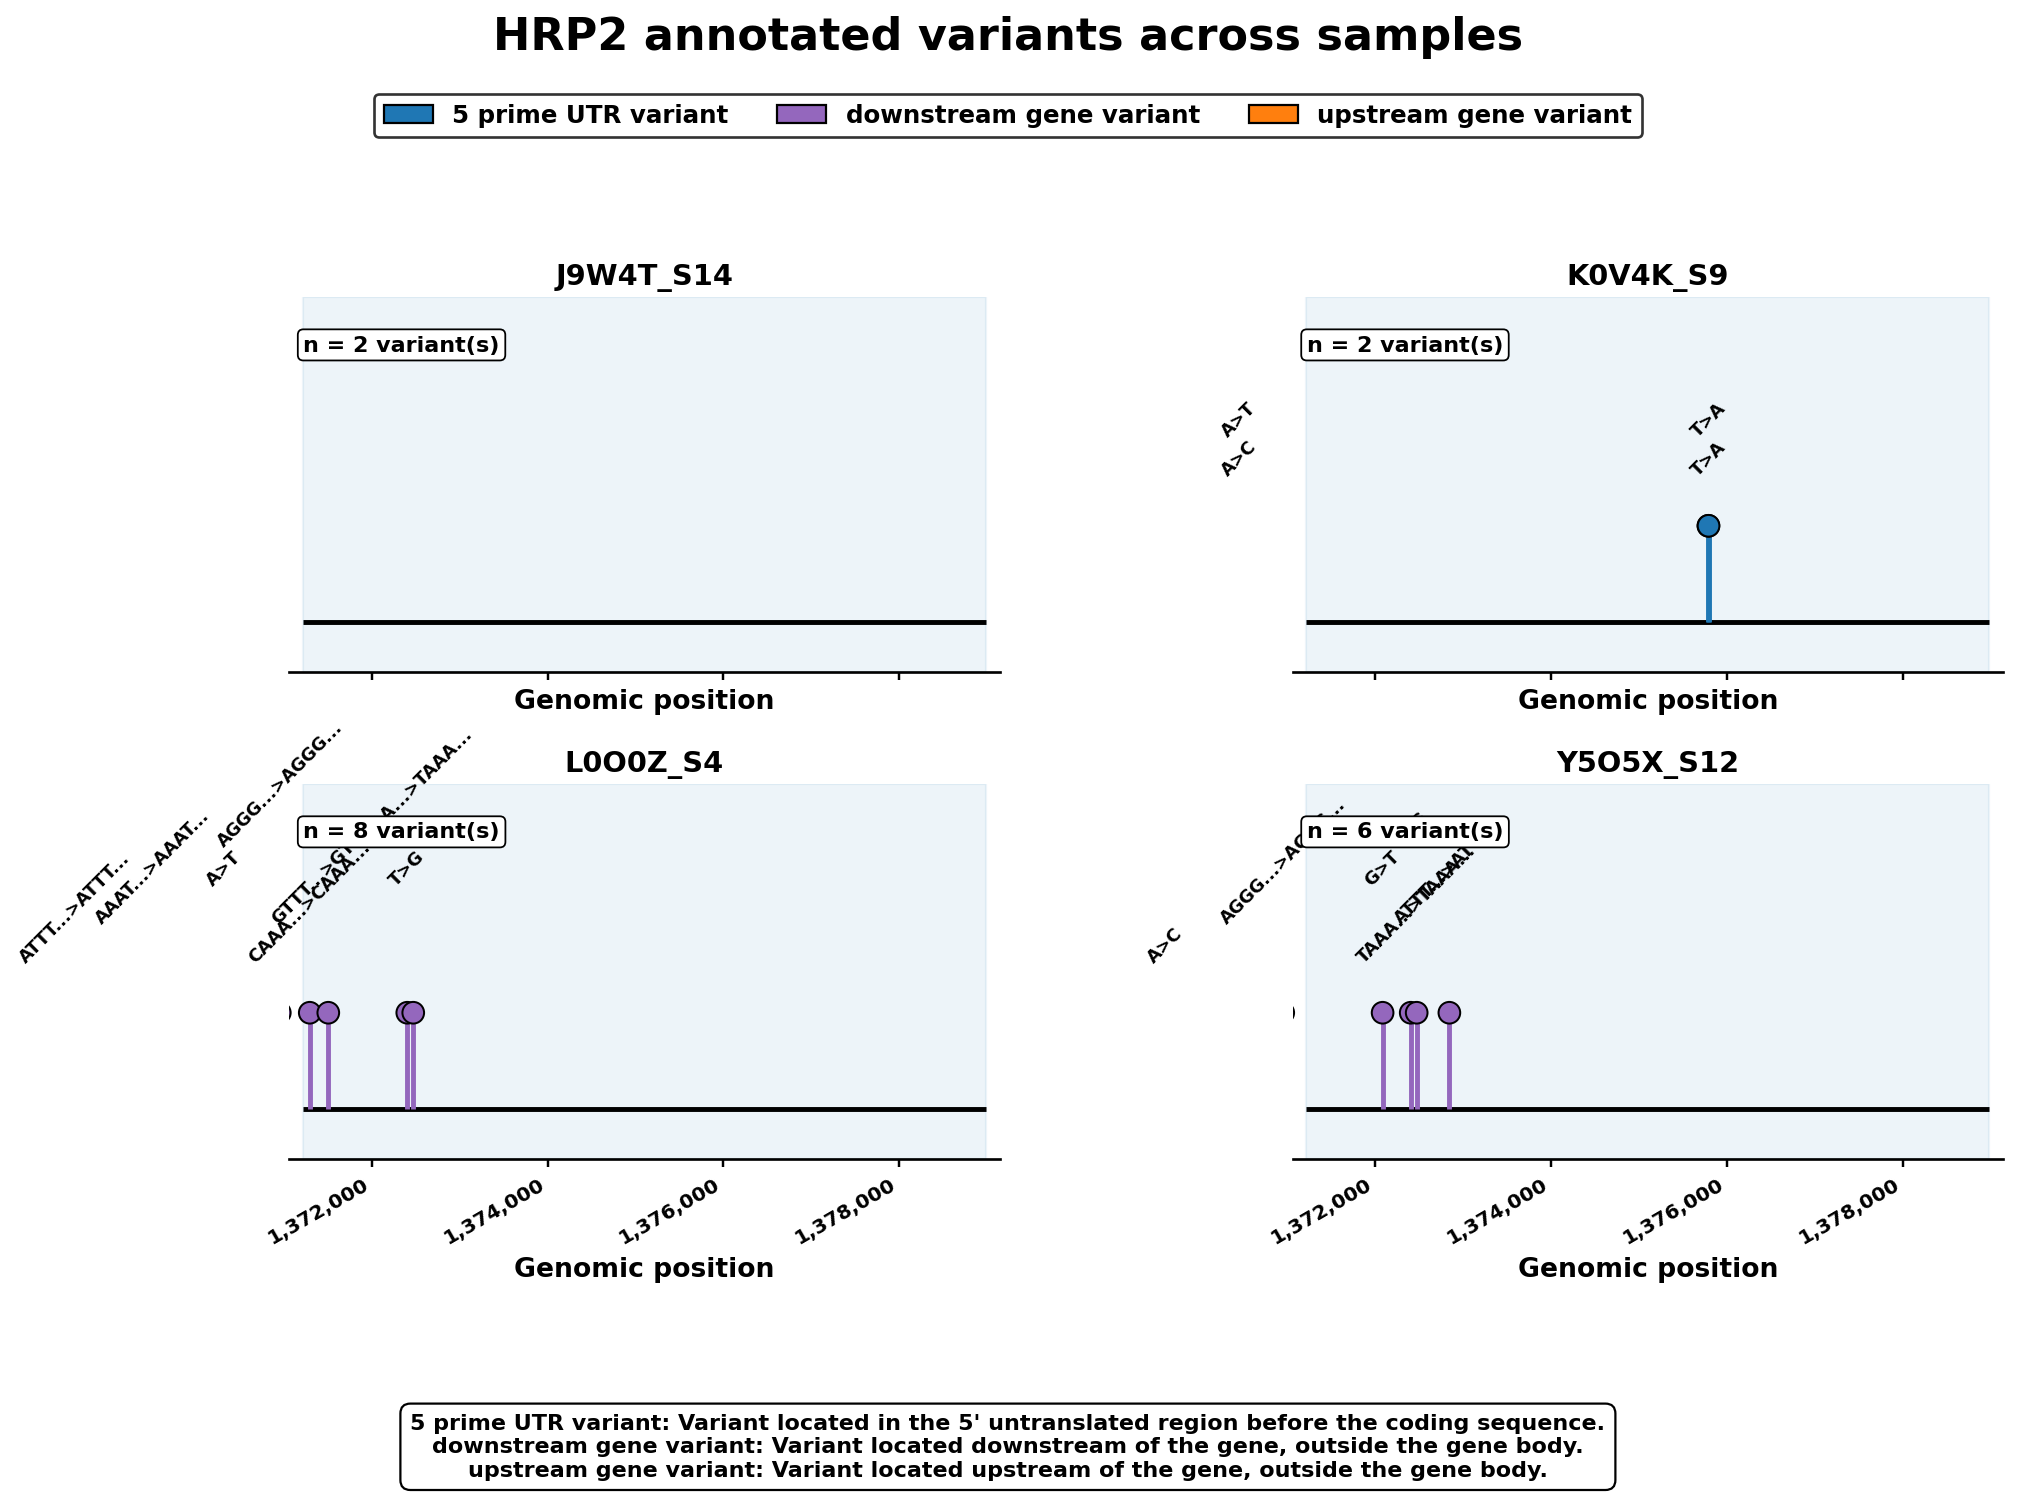

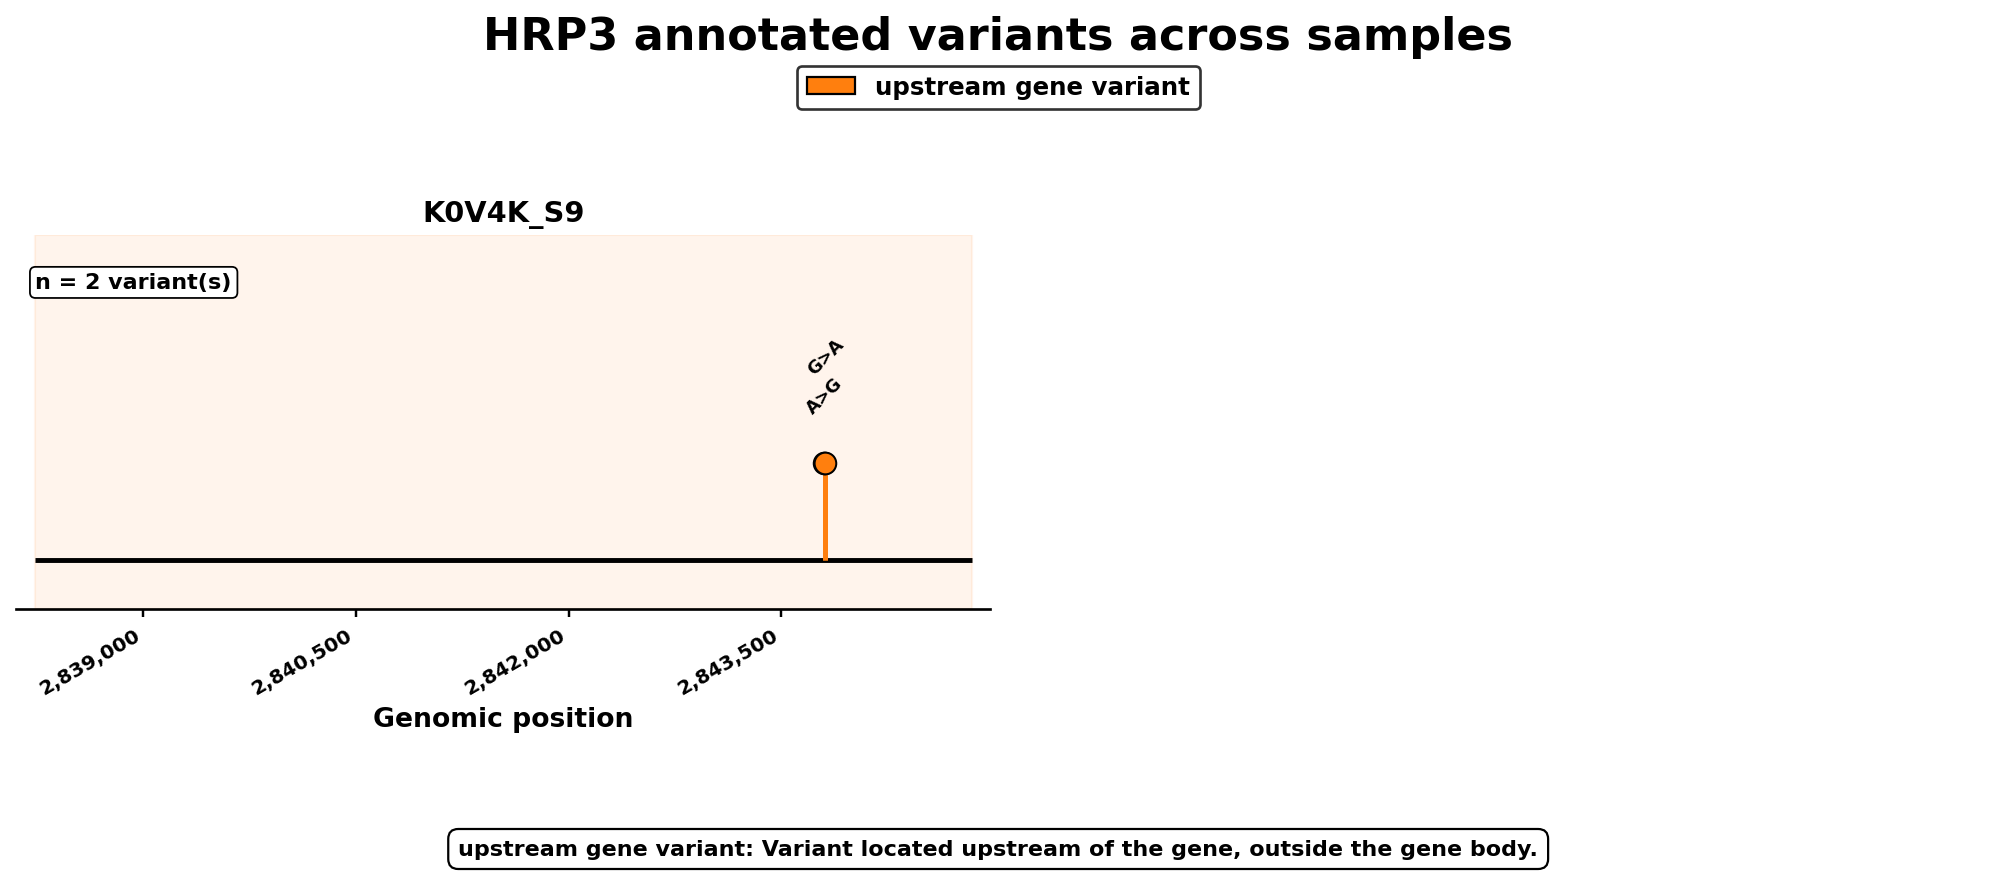

,sample,gene,gene_id,chrom,genomic_position,relative_position,ref,alt,variant_label,qual,filter,effect,impact,transcript,hgvs_c
0,J9W4T_S14,HRP2,PF3D7_0831800,Pf3D7_08_v3,1381868,10657,A,C,A>C,203.417,PASS,upstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.-6569T>G
1,J9W4T_S14,HRP2,PF3D7_0831800,Pf3D7_08_v3,1381870,10659,A,T,A>T,203.417,PASS,upstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.-6571T>A
2,K0V4K_S9,HRP2,PF3D7_0831800,Pf3D7_08_v3,1375789,4578,T,A,T>A,228.412,PASS,5_prime_UTR_variant,MODIFIER,PF3D7_0831800.1,c.-490A>T
3,K0V4K_S9,HRP2,PF3D7_0831800,Pf3D7_08_v3,1375791,4580,T,A,T>A,228.408,PASS,5_prime_UTR_variant,MODIFIER,PF3D7_0831800.1,c.-492A>T
6,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1368616,-2595,ATTTTTTTTTTTTT,ATTTTTTTTTTTTTT,ATTTTTTTTTTTTT>ATTTTTTTTTTTTTT,228.197,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*5606_*5607insA
7,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1369500,-1711,AAATA,AAATACAATA,AAATA>AAATACAATA,193.317,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*4731_*4732insTATTG
8,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1370318,-893,A,T,A>T,225.417,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*3918T>A
9,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1370950,-261,AGGGGGGGGG,"AGGGGGGGGGG,AGGGGGGGGGGG","AGGGGGGGGG>AGGGGGGGGGG,AGGGGGGGGGGG",165.78,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*3276_*3277insC
11,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1371291,80,CAAAAA,CAAAAAA,CAAAAA>CAAAAAA,221.727,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*2939_*2940insT
12,L0O0Z_S4,HRP2,PF3D7_0831800,Pf3D7_08_v3,1371502,291,GTTTTTT,GTTTTTTT,GTTTTTT>GTTTTTTT,222.348,PASS,downstream_gene_variant,MODIFIER,PF3D7_0831800.1,c.*2727_*2728insA


In [28]:
import gzip
import re
import math
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

VCF_FILES = sorted(ROOT.glob("samples/*/variants/*.raw.filtered.ann.vcf.gz"))

genes = {
    "HRP2": {
        "gene_id": "PF3D7_0831800",
        "chrom": "Pf3D7_08_v3",
        "start": 1371212,
        "end": 1378988,
        "color": "#1f77b4"
    },
    "HRP3": {
        "gene_id": "PF3D7_1372200",
        "chrom": "Pf3D7_13_v3",
        "start": 2838236,
        "end": 2844840,
        "color": "#ff7f0e"
    }
}

effect_colors = {
    "5_prime_UTR_variant": "#1f77b4",
    "3_prime_UTR_variant": "#17becf",
    "upstream_gene_variant": "#ff7f0e",
    "downstream_gene_variant": "#9467bd",
    "intergenic_region": "#7f7f7f",
    "intron_variant": "#8c564b",
    "non_coding_transcript_exon_variant": "#2ca02c",
    "non_coding_transcript_variant": "#bcbd22",
    "synonymous_variant": "#98df8a",
    "missense_variant": "#d62728",
    "frameshift_variant": "#000000",
    "stop_gained": "#e377c2"
}

effect_explanations = {
    "5_prime_UTR_variant": "Variant located in the 5' untranslated region before the coding sequence.",
    "3_prime_UTR_variant": "Variant located in the 3' untranslated region after the coding sequence.",
    "upstream_gene_variant": "Variant located upstream of the gene, outside the gene body.",
    "downstream_gene_variant": "Variant located downstream of the gene, outside the gene body.",
    "intergenic_region": "Variant located between annotated genes.",
    "intron_variant": "Variant located inside an intron.",
    "non_coding_transcript_exon_variant": "Variant located in an exon of a non-coding transcript.",
    "non_coding_transcript_variant": "Variant located in a non-coding transcript region.",
    "synonymous_variant": "Coding variant that does not change the amino acid.",
    "missense_variant": "Coding variant that changes the amino acid.",
    "frameshift_variant": "Coding indel that shifts the reading frame.",
    "stop_gained": "Coding variant that creates a premature stop codon."
}

rows = []

for vcf in VCF_FILES:
    sample = vcf.parts[-3]

    if "Undetermined" in sample:
        continue

    with gzip.open(vcf, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue

            fields = line.rstrip("\n").split("\t")

            if len(fields) < 8:
                continue

            chrom = fields[0]
            pos = int(fields[1])
            ref = fields[3]
            alt = fields[4]
            qual = fields[5]
            filt = fields[6]
            info = fields[7]

            ann_match = re.search(r"ANN=([^;]+)", info)

            if not ann_match:
                continue

            for ann in ann_match.group(1).split(","):
                a = ann.split("|")

                if len(a) < 10:
                    continue

                effect = a[1]
                impact = a[2]
                gene_id = a[4]
                transcript = a[6] if len(a) > 6 else ""
                hgvs_c = a[9] if len(a) > 9 else ""

                for gene_name, g in genes.items():
                    if gene_id == g["gene_id"]:
                        rows.append({
                            "sample": sample,
                            "gene": gene_name,
                            "gene_id": gene_id,
                            "chrom": chrom,
                            "genomic_position": pos,
                            "relative_position": pos - g["start"] + 1,
                            "ref": ref,
                            "alt": alt,
                            "variant_label": f"{ref}>{alt}",
                            "qual": qual,
                            "filter": filt,
                            "effect": effect,
                            "impact": impact,
                            "transcript": transcript,
                            "hgvs_c": hgvs_c
                        })

variants_gene = pd.DataFrame(rows)

if not variants_gene.empty:
    variants_gene = variants_gene.drop_duplicates(
        subset=["sample", "gene", "genomic_position", "ref", "alt", "effect"]
    ).sort_values(["gene", "sample", "genomic_position"])

variants_gene.to_csv(
    OUTDIR / "hrp2_hrp3_regional_annotated_variants.tsv",
    sep="\t",
    index=False
)

def savefig(name):
    for ext in ["png", "pdf", "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")

def shorten_variant_label(ref, alt, max_len=12):
    label = f"{ref}>{alt}"
    if len(label) <= max_len:
        return label
    return f"{ref[:4]}...>{alt[:4]}..."

def plot_gene_variant_lollipop(gene_name):
    g = genes[gene_name]
    sub = variants_gene[variants_gene["gene"] == gene_name].copy()

    if sub.empty:
        print(f"No annotated variants found for {gene_name}")
        return

    samples = sorted(sub["sample"].unique())
    n_samples = len(samples)

    ncols = 2 if n_samples <= 4 else 3
    nrows = math.ceil(n_samples / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6.4 * ncols, 3.9 * nrows + 1.4),
        sharex=True,
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    xmin = g["start"]
    xmax = g["end"]
    gene_len = xmax - xmin + 1

    for ax, sample in zip(axes, samples):
        sdf = sub[sub["sample"] == sample].copy()
        sdf = sdf.sort_values("genomic_position").reset_index(drop=True)

        ax.axvspan(xmin, xmax, color=g["color"], alpha=0.08)
        ax.hlines(1, xmin, xmax, color="black", linewidth=2.2)

        colors = [effect_colors.get(e, "#7f7f7f") for e in sdf["effect"]]

        ax.vlines(
            sdf["genomic_position"],
            1,
            1.35,
            color=colors,
            linewidth=2.2
        )

        ax.scatter(
            sdf["genomic_position"],
            np.repeat(1.35, len(sdf)),
            c=colors,
            s=95,
            edgecolor="black",
            linewidth=0.9,
            zorder=3
        )

        for i, (_, r) in enumerate(sdf.iterrows()):
            label = shorten_variant_label(r["ref"], r["alt"])
            y_label = [1.52, 1.66, 1.80, 1.94][i % 4]

            ax.text(
                r["genomic_position"],
                y_label,
                label,
                ha="center",
                va="bottom",
                rotation=45,
                fontsize=8,
                fontweight="bold"
            )

        ax.text(
            0.02,
            0.90,
            f"n = {len(sdf)} variant(s)",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", linewidth=0.8, boxstyle="round,pad=0.25")
        )

        ax.set_title(sample, fontsize=13, fontweight="bold")
        ax.set_ylim(0.82, 2.18)
        ax.set_xlim(xmin - gene_len * 0.02, xmax + gene_len * 0.02)
        ax.set_yticks([])
        ax.set_xlabel("Genomic position", fontweight="bold", fontsize=12)

        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
        ax.tick_params(axis="x", labelsize=9, width=1.1)

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
            label.set_rotation(30)
            label.set_ha("right")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

    for ax in axes[n_samples:]:
        ax.axis("off")

    used_effects = sorted(sub["effect"].unique())

    legend_handles = [
        Patch(
            facecolor=effect_colors.get(e, "#7f7f7f"),
            edgecolor="black",
            label=e.replace("_", " ")
        )
        for e in used_effects
    ]

    legend = fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=min(3, len(legend_handles)),
        frameon=True,
        fontsize=11
    )

    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.2)

    explanation_text = "\n".join(
        [
            f"{e.replace('_', ' ')}: {effect_explanations.get(e, 'Annotated variant effect.')}"
            for e in used_effects
        ]
    )

    fig.text(
        0.5,
        0.015,
        explanation_text,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="black", linewidth=1.0, boxstyle="round,pad=0.45")
    )

    fig.suptitle(
        f"{gene_name} annotated variants across samples",
        fontsize=20,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout(rect=[0, 0.13, 1, 0.91])
    savefig(f"{gene_name.lower()}_annotated_variant_lollipop_panels_clear")
    plt.show()

plot_gene_variant_lollipop("HRP2")
plot_gene_variant_lollipop("HRP3")

variants_gene

In [29]:
import math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

OUTDIR.mkdir(parents=True, exist_ok=True)

genes = {
    "HRP2": {
        "chrom": "Pf3D7_08_v3",
        "start": 1371212,
        "end": 1378988,
        "color": "#1f77b4"
    },
    "HRP3": {
        "chrom": "Pf3D7_13_v3",
        "start": 2838236,
        "end": 2844840,
        "color": "#ff7f0e"
    }
}

DEPTH_FILES = sorted(ROOT.glob("samples/*/coverage/*.gene_depth.tsv"))

def savefig(name):
    for ext in ["png", "pdf", "tif"]:
        plt.savefig(OUTDIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")

def read_depth_file(path):
    sample = path.parent.parent.name
    df = pd.read_csv(path, sep="\t", header=None, names=["chrom", "pos", "depth"])
    df["sample"] = sample
    return df

depth = pd.concat([read_depth_file(p) for p in DEPTH_FILES], ignore_index=True)
depth = depth[~depth["sample"].str.contains("Undetermined", na=False)].copy()

gene_calls = gene_calls[~gene_calls["sample"].str.contains("Undetermined", na=False)].copy()

def clean_gene(g):
    g = str(g)
    if "HRP2" in g:
        return "HRP2"
    if "HRP3" in g:
        return "HRP3"
    return g

gene_calls["gene_label"] = gene_calls["gene"].map(clean_gene)
gene_calls = gene_calls[gene_calls["gene_label"].isin(["HRP2", "HRP3"])].copy()

def classify_gene(row):
    mean_depth = row["mean_depth"]
    breadth_1x = row["breadth_1x_pct"]
    breadth_5x = row["breadth_5x_pct"]

    if breadth_5x >= 80 and mean_depth >= 5:
        return "Present"
    elif breadth_1x < 20 and mean_depth < 1:
        return "Deleted"
    elif breadth_1x >= 20 and breadth_5x < 80:
        return "Partial/low coverage"
    else:
        return "Low confidence"

gene_calls["final_call"] = gene_calls.apply(classify_gene, axis=1)

call_colors = {
    "Present": "#1f77b4",
    "Deleted": "#d62728",
    "Partial/low coverage": "#ff7f0e",
    "Low confidence": "#7f7f7f"
}

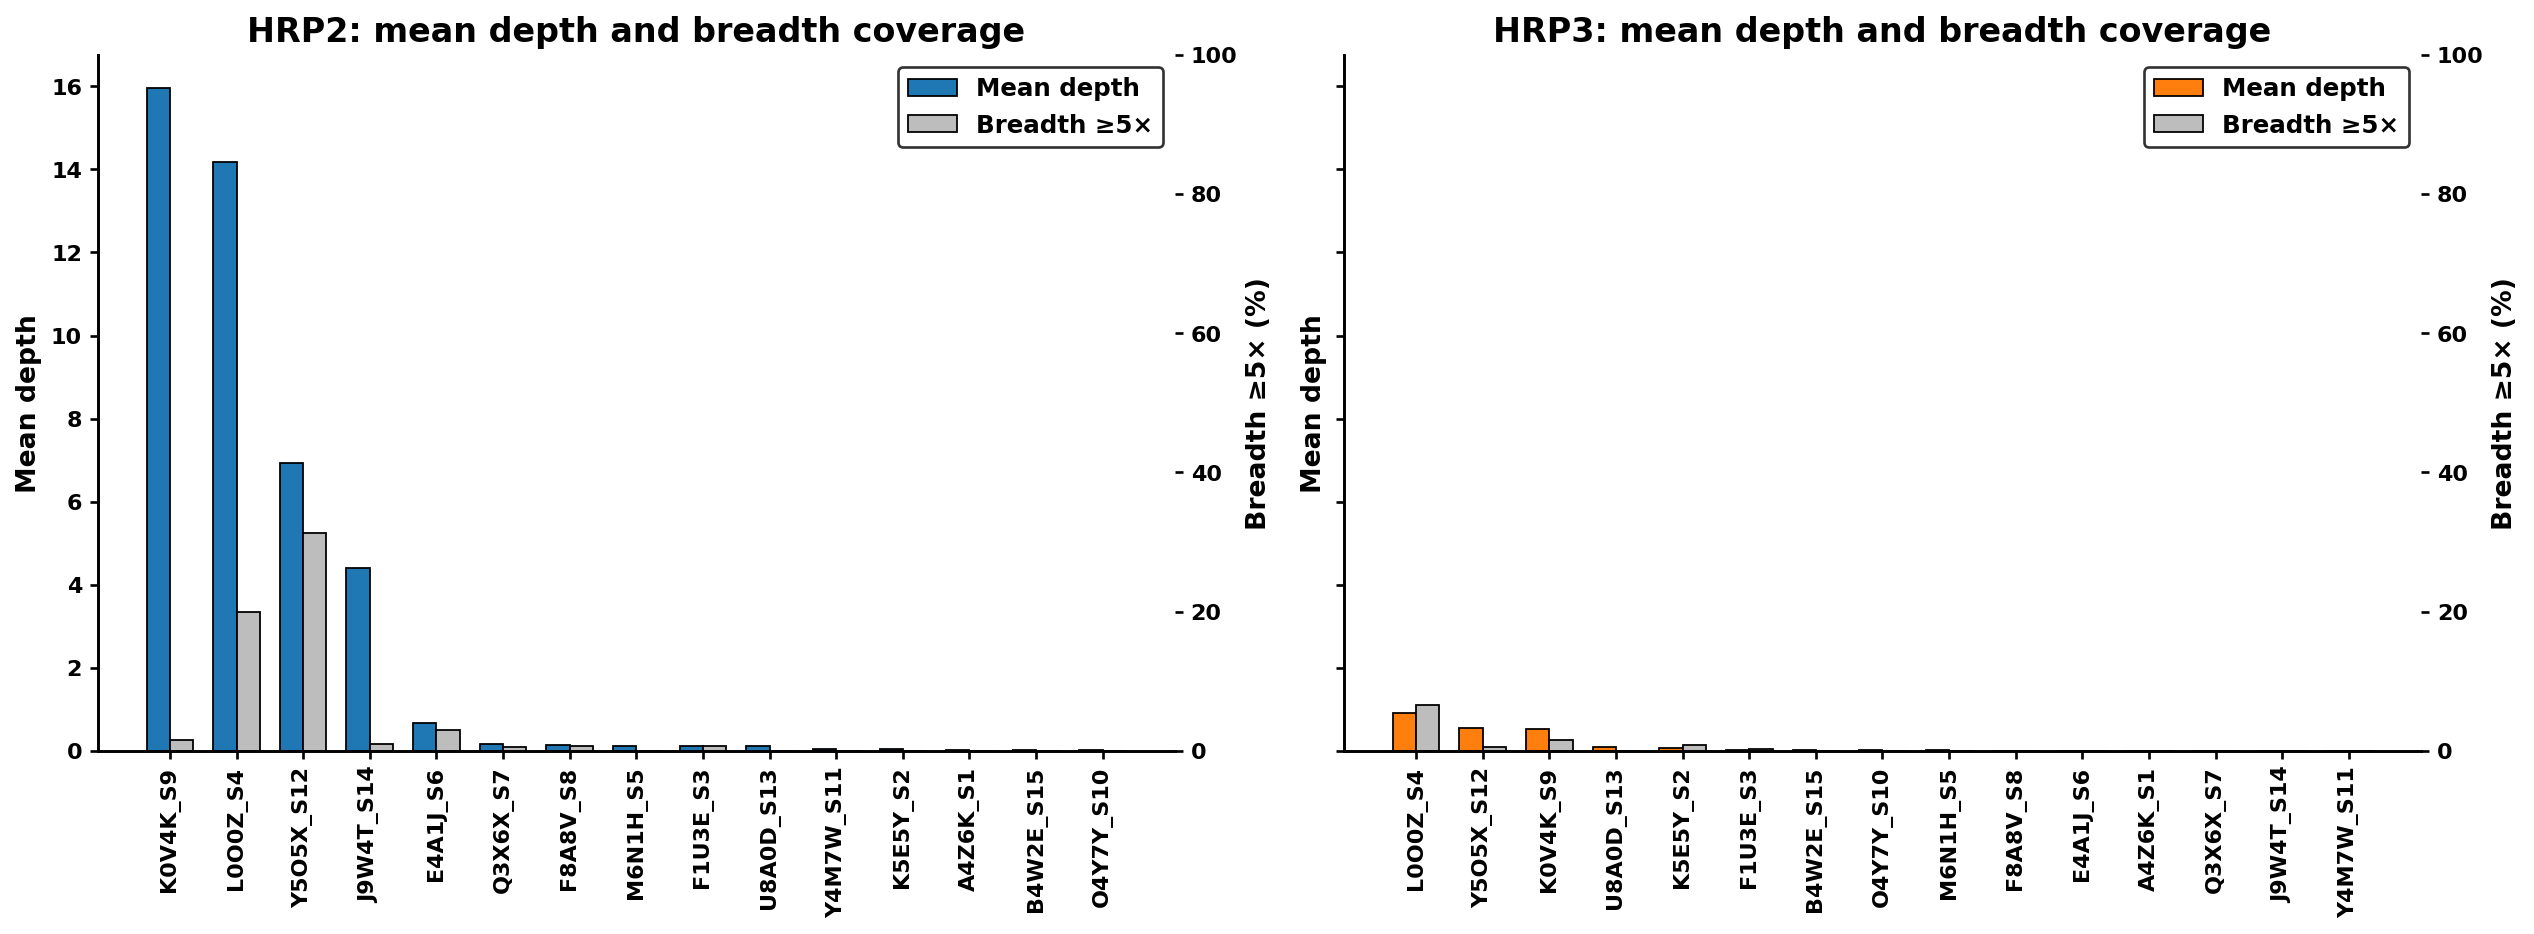

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, gene_name in zip(axes, ["HRP2", "HRP3"]):
    sub = gene_calls[gene_calls["gene_label"] == gene_name].copy()
    sub = sub.sort_values("mean_depth", ascending=False)

    x = np.arange(len(sub))
    width = 0.35

    ax.bar(
        x - width/2,
        sub["mean_depth"],
        width=width,
        color=genes[gene_name]["color"],
        edgecolor="black",
        linewidth=0.8,
        label="Mean depth"
    )

    ax2 = ax.twinx()

    ax2.bar(
        x + width/2,
        sub["breadth_5x_pct"],
        width=width,
        color="#bdbdbd",
        edgecolor="black",
        linewidth=0.8,
        label="Breadth ≥5×"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["sample"], rotation=90, fontweight="bold")
    ax.set_ylabel("Mean depth", fontweight="bold")
    ax2.set_ylabel("Breadth ≥5× (%)", fontweight="bold")
    ax.set_title(f"{gene_name}: mean depth and breadth coverage", fontweight="bold", fontsize=15)

    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax2.set_ylim(0, 100)

    ax.tick_params(axis="both", labelsize=10, width=1.2)
    ax2.tick_params(axis="y", labelsize=10, width=1.2)

    for label in ax.get_yticklabels() + ax2.get_yticklabels():
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    legend = ax.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper right",
        frameon=True,
        fontsize=11
    )
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
savefig("strong_01_mean_depth_and_breadth_5x")
plt.show()

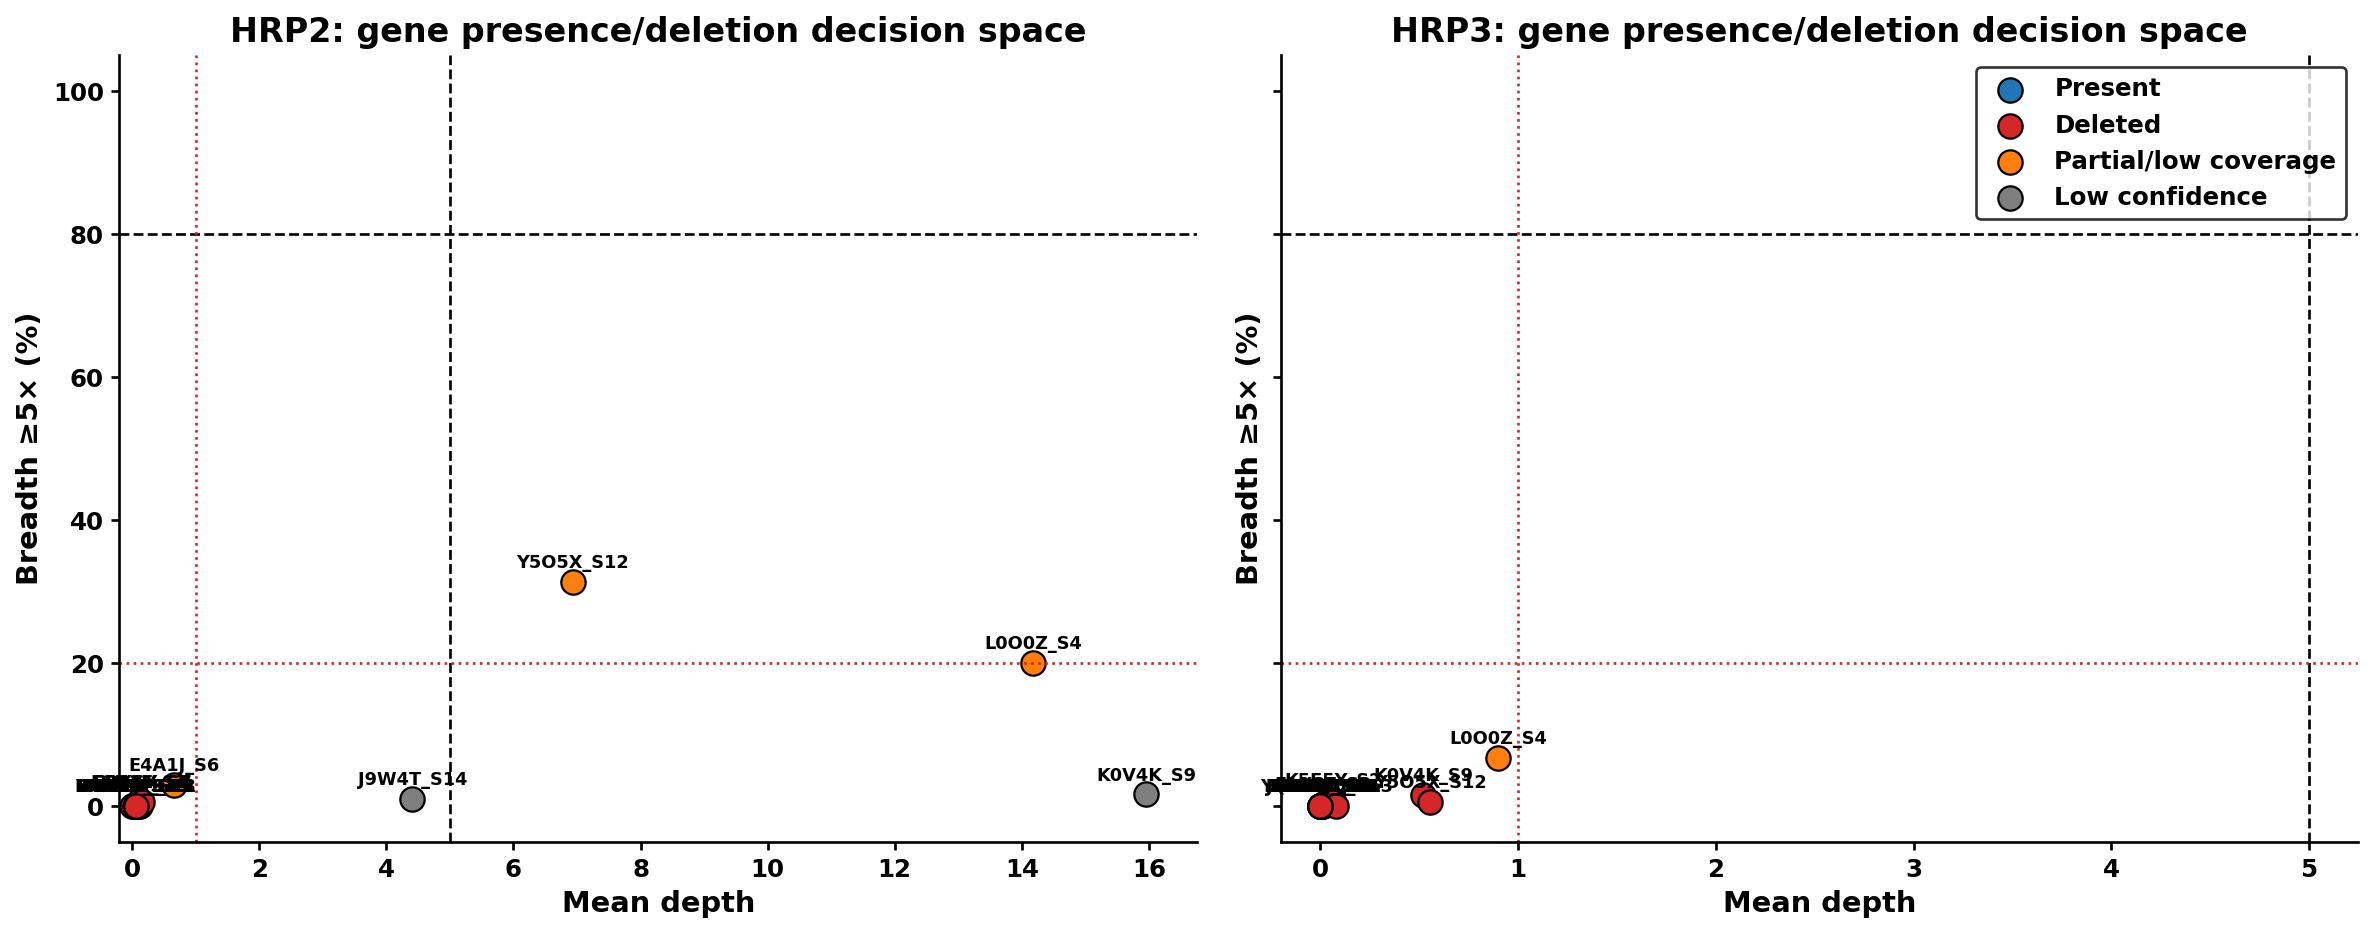

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, gene_name in zip(axes, ["HRP2", "HRP3"]):
    sub = gene_calls[gene_calls["gene_label"] == gene_name].copy()

    for call, c in call_colors.items():
        ss = sub[sub["final_call"] == call]
        ax.scatter(
            ss["mean_depth"],
            ss["breadth_5x_pct"],
            s=120,
            color=c,
            edgecolor="black",
            linewidth=1.0,
            label=call
        )

    for _, r in sub.iterrows():
        ax.text(
            r["mean_depth"],
            r["breadth_5x_pct"] + 2,
            r["sample"],
            fontsize=8,
            fontweight="bold",
            ha="center"
        )

    ax.axhline(80, color="black", linestyle="--", linewidth=1.2)
    ax.axvline(5, color="black", linestyle="--", linewidth=1.2)
    ax.axhline(20, color="#d62728", linestyle=":", linewidth=1.2)
    ax.axvline(1, color="#d62728", linestyle=":", linewidth=1.2)

    ax.set_xlabel("Mean depth", fontweight="bold", fontsize=13)
    ax.set_ylabel("Breadth ≥5× (%)", fontweight="bold", fontsize=13)
    ax.set_title(f"{gene_name}: gene presence/deletion decision space", fontweight="bold", fontsize=15)
    ax.set_ylim(-5, 105)
    ax.set_xlim(left=-0.2)
    ax.tick_params(axis="both", labelsize=11, width=1.2)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend = axes[1].legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
savefig("strong_02_mean_depth_vs_breadth_scatter")
plt.show()

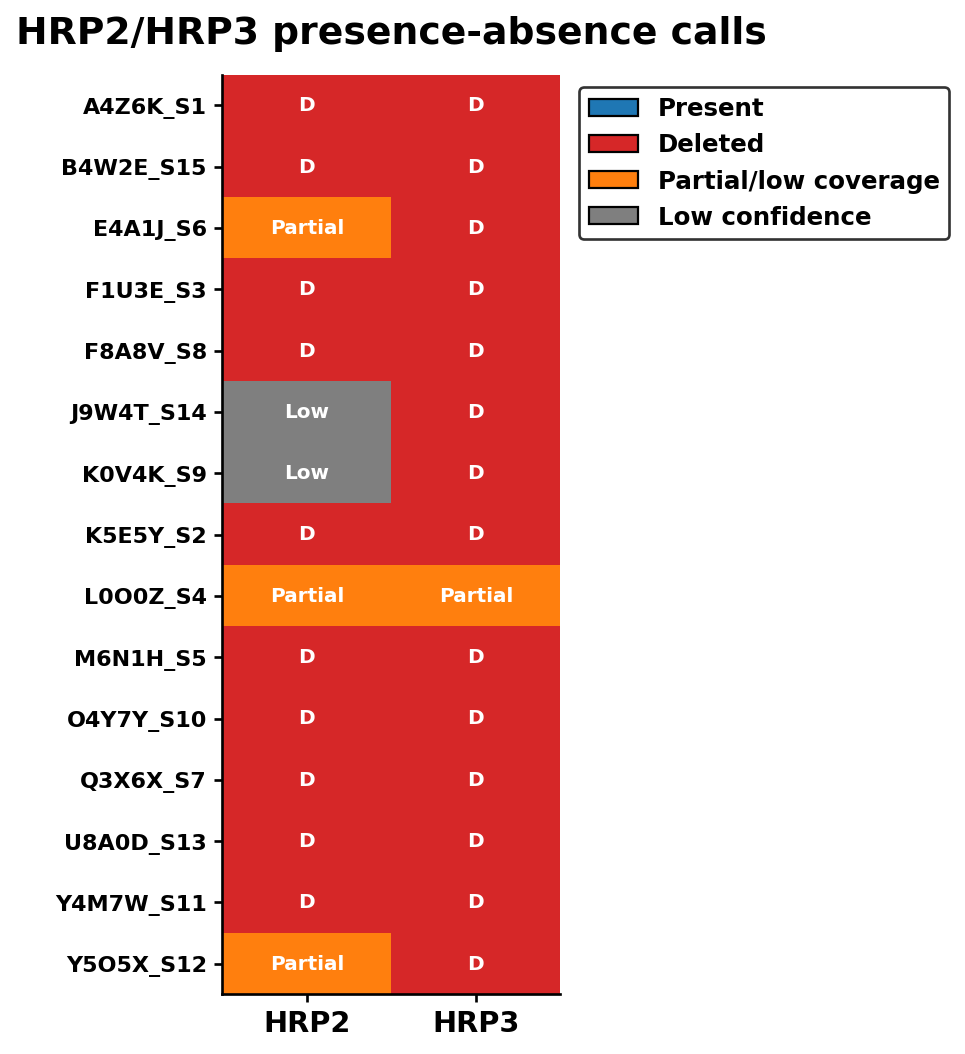

In [37]:
summary_df = gene_calls[
    [
        "sample",
        "gene_label",
        "mean_depth",
        "breadth_1x_pct",
        "breadth_5x_pct",
        "breadth_10x_pct",
        "final_call"
    ]
].copy()

summary_df = summary_df.sort_values(["gene_label", "final_call", "sample"])
summary_df.to_csv(OUTDIR / "hrp2_hrp3_presence_absence_final_calls.tsv", sep="\t", index=False)

heat_call = (
    summary_df
    .pivot(index="sample", columns="gene_label", values="final_call")
    .fillna("Low confidence")
)

heat_call = heat_call.reindex(columns=["HRP2", "HRP3"]).fillna("Low confidence")

call_to_num = {
    "Deleted": 0,
    "Partial/low coverage": 1,
    "Low confidence": 2,
    "Present": 3
}

heat_num = heat_call.replace(call_to_num).astype(float)

samples = sorted(heat_num.index.tolist())
heat_num = heat_num.reindex(samples)
heat_call = heat_call.reindex(samples)

fig, ax = plt.subplots(figsize=(6, max(6, len(samples) * 0.45)))

cmap = plt.matplotlib.colors.ListedColormap([
    call_colors["Deleted"],
    call_colors["Partial/low coverage"],
    call_colors["Low confidence"],
    call_colors["Present"]
])

im = ax.imshow(heat_num.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=0, vmax=3)

ax.set_xticks(np.arange(2))
ax.set_xticklabels(["HRP2", "HRP3"], fontsize=13, fontweight="bold")
ax.set_yticks(np.arange(len(samples)))
ax.set_yticklabels(samples, fontsize=10, fontweight="bold")

for i in range(heat_num.shape[0]):
    for j in range(heat_num.shape[1]):
        call = heat_call.iloc[i, j]
        label = {
            "Present": "P",
            "Deleted": "D",
            "Partial/low coverage": "Partial",
            "Low confidence": "Low"
        }.get(call, "Low")
        ax.text(j, i, label, ha="center", va="center", color="white", fontsize=9, fontweight="bold")

legend_handles = [
    Patch(facecolor=call_colors["Present"], edgecolor="black", label="Present"),
    Patch(facecolor=call_colors["Deleted"], edgecolor="black", label="Deleted"),
    Patch(facecolor=call_colors["Partial/low coverage"], edgecolor="black", label="Partial/low coverage"),
    Patch(facecolor=call_colors["Low confidence"], edgecolor="black", label="Low confidence")
]

legend = ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=11
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

ax.set_title("HRP2/HRP3 presence-absence calls", fontsize=17, fontweight="bold", pad=14)

plt.tight_layout()
savefig("strong_03_presence_absence_call_heatmap")
plt.show()

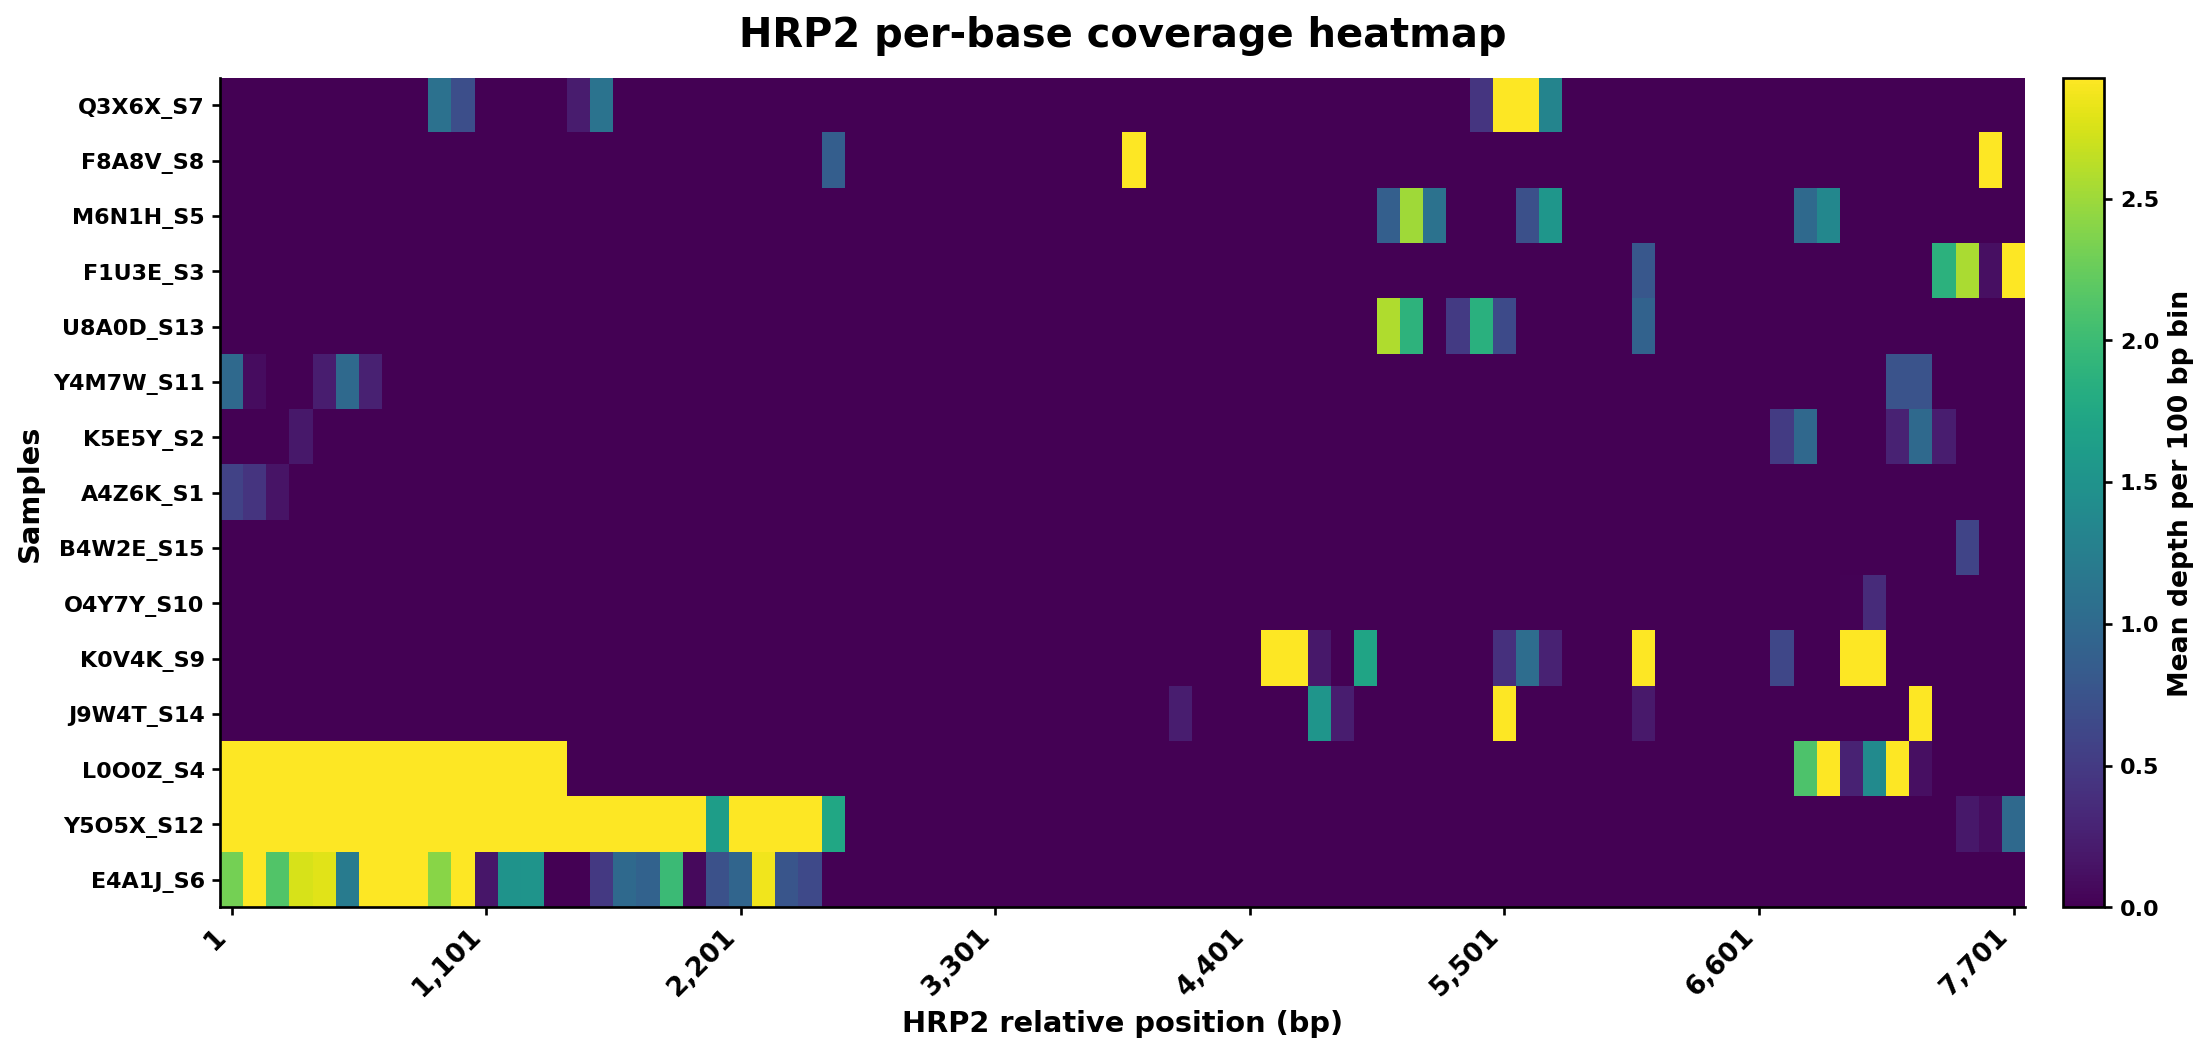

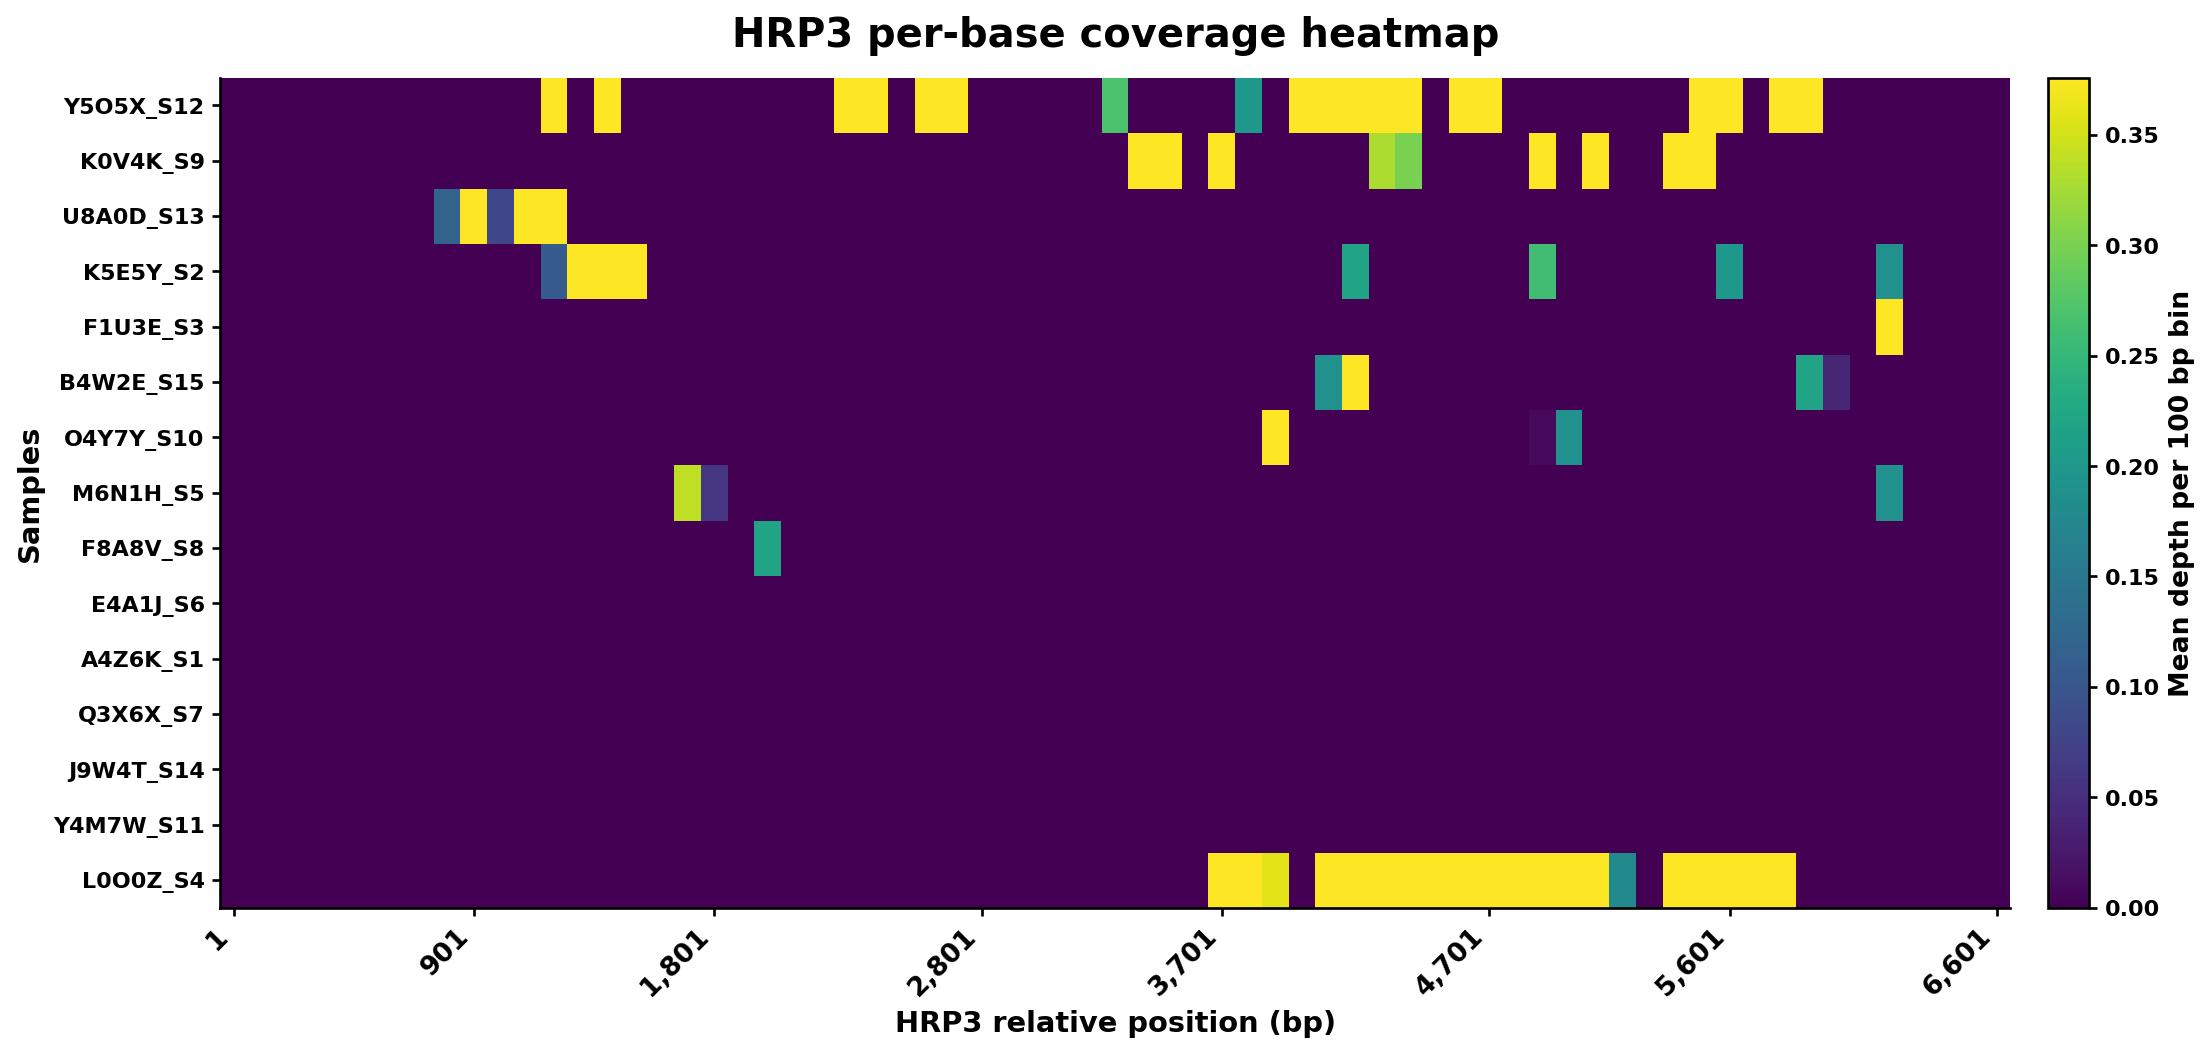

In [38]:
def coverage_matrix(gene_name, bin_size=100):
    g = genes[gene_name]
    sub = depth[
        (depth["chrom"] == g["chrom"]) &
        (depth["pos"] >= g["start"]) &
        (depth["pos"] <= g["end"])
    ].copy()

    sub["bin"] = ((sub["pos"] - g["start"]) // bin_size) * bin_size + 1

    mat = (
        sub.groupby(["sample", "bin"])["depth"]
        .mean()
        .reset_index()
        .pivot(index="sample", columns="bin", values="depth")
        .fillna(0)
    )

    order = (
        gene_calls[gene_calls["gene_label"] == gene_name]
        .sort_values(["final_call", "mean_depth"], ascending=[True, False])["sample"]
        .tolist()
    )

    mat = mat.reindex([s for s in order if s in mat.index])
    return mat

def plot_coverage_heatmap(gene_name):
    mat = coverage_matrix(gene_name, bin_size=100)

    fig, ax = plt.subplots(figsize=(14, max(5, mat.shape[0] * 0.45)))

    vmax = np.nanpercentile(mat.values, 95)
    if vmax <= 0:
        vmax = 1

    im = ax.imshow(mat.values, aspect="auto", interpolation="nearest", cmap="viridis", vmin=0, vmax=vmax)

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index.tolist(), fontsize=10, fontweight="bold")

    xticks = np.linspace(0, mat.shape[1] - 1, min(8, mat.shape[1])).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(mat.columns[i]):,}" for i in xticks], rotation=45, ha="right", fontweight="bold")

    ax.set_xlabel(f"{gene_name} relative position (bp)", fontweight="bold", fontsize=13)
    ax.set_ylabel("Samples", fontweight="bold", fontsize=13)
    ax.set_title(f"{gene_name} per-base coverage heatmap", fontweight="bold", fontsize=18, pad=14)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Mean depth per 100 bp bin", fontweight="bold")
    cbar.ax.tick_params(labelsize=10, width=1.2)

    for label in cbar.ax.get_yticklabels():
        label.set_fontweight("bold")

    plt.tight_layout()
    savefig(f"strong_04_{gene_name.lower()}_coverage_heatmap")
    plt.show()

plot_coverage_heatmap("HRP2")
plot_coverage_heatmap("HRP3")

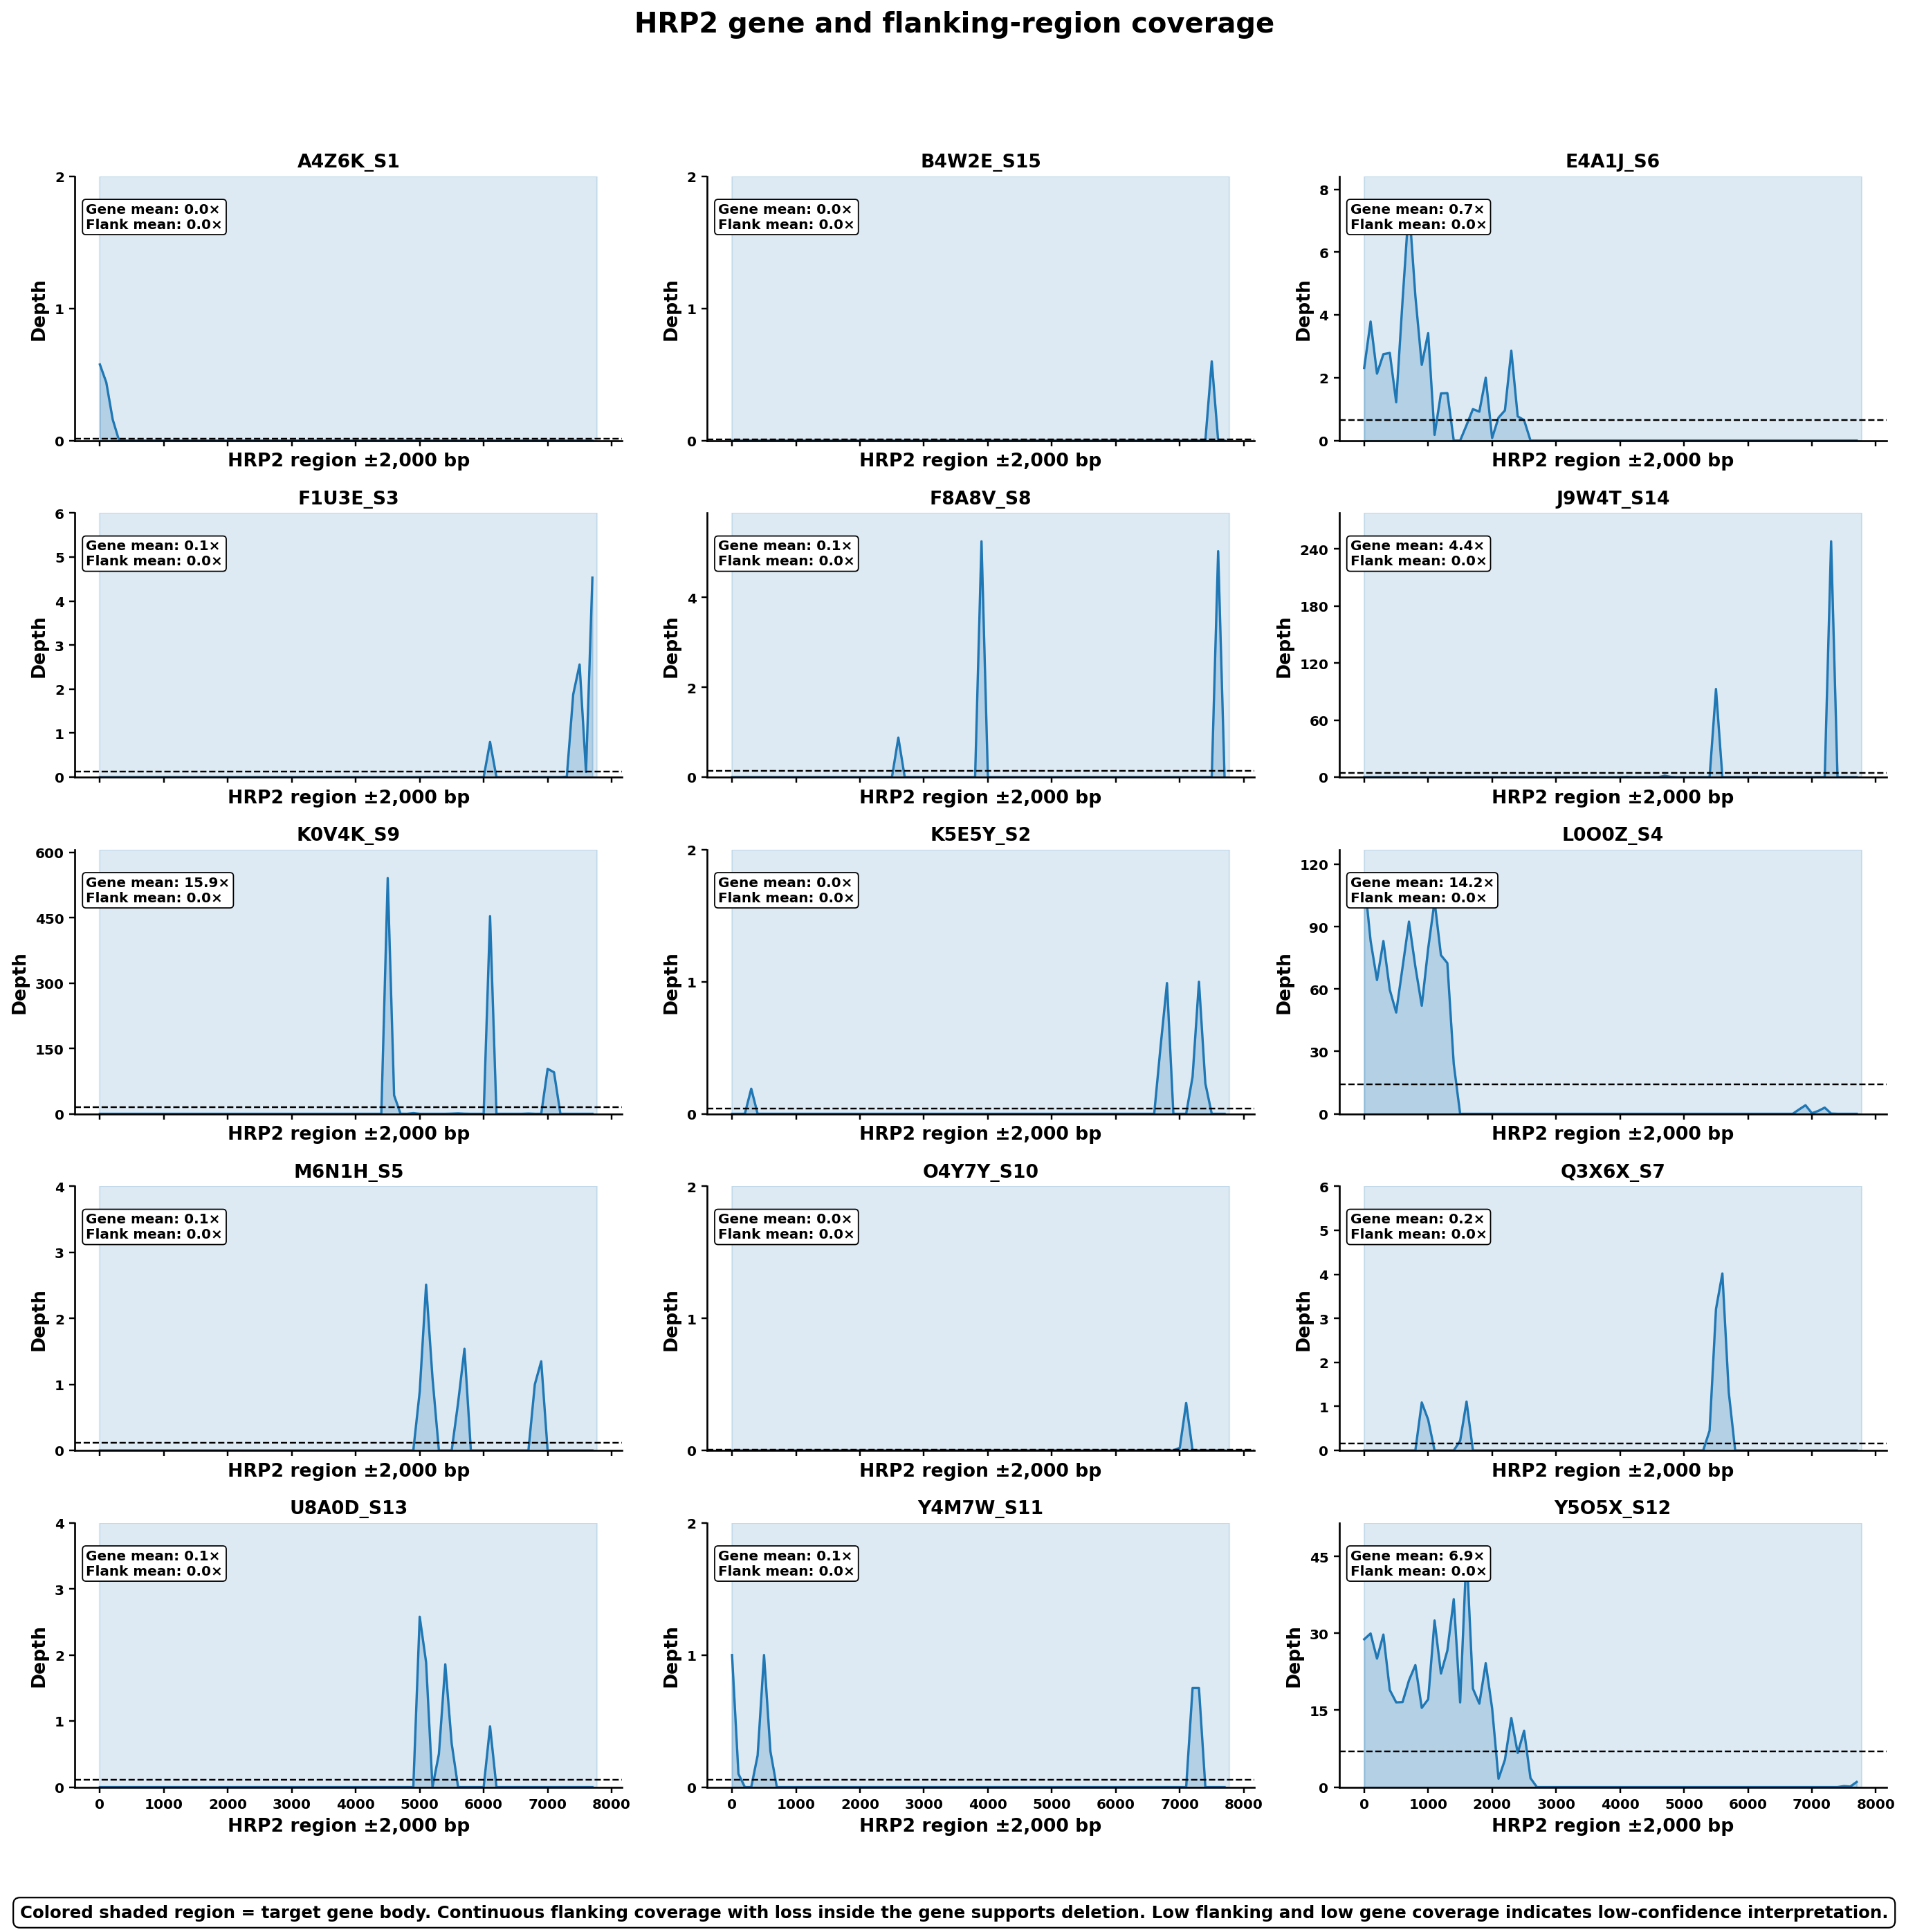

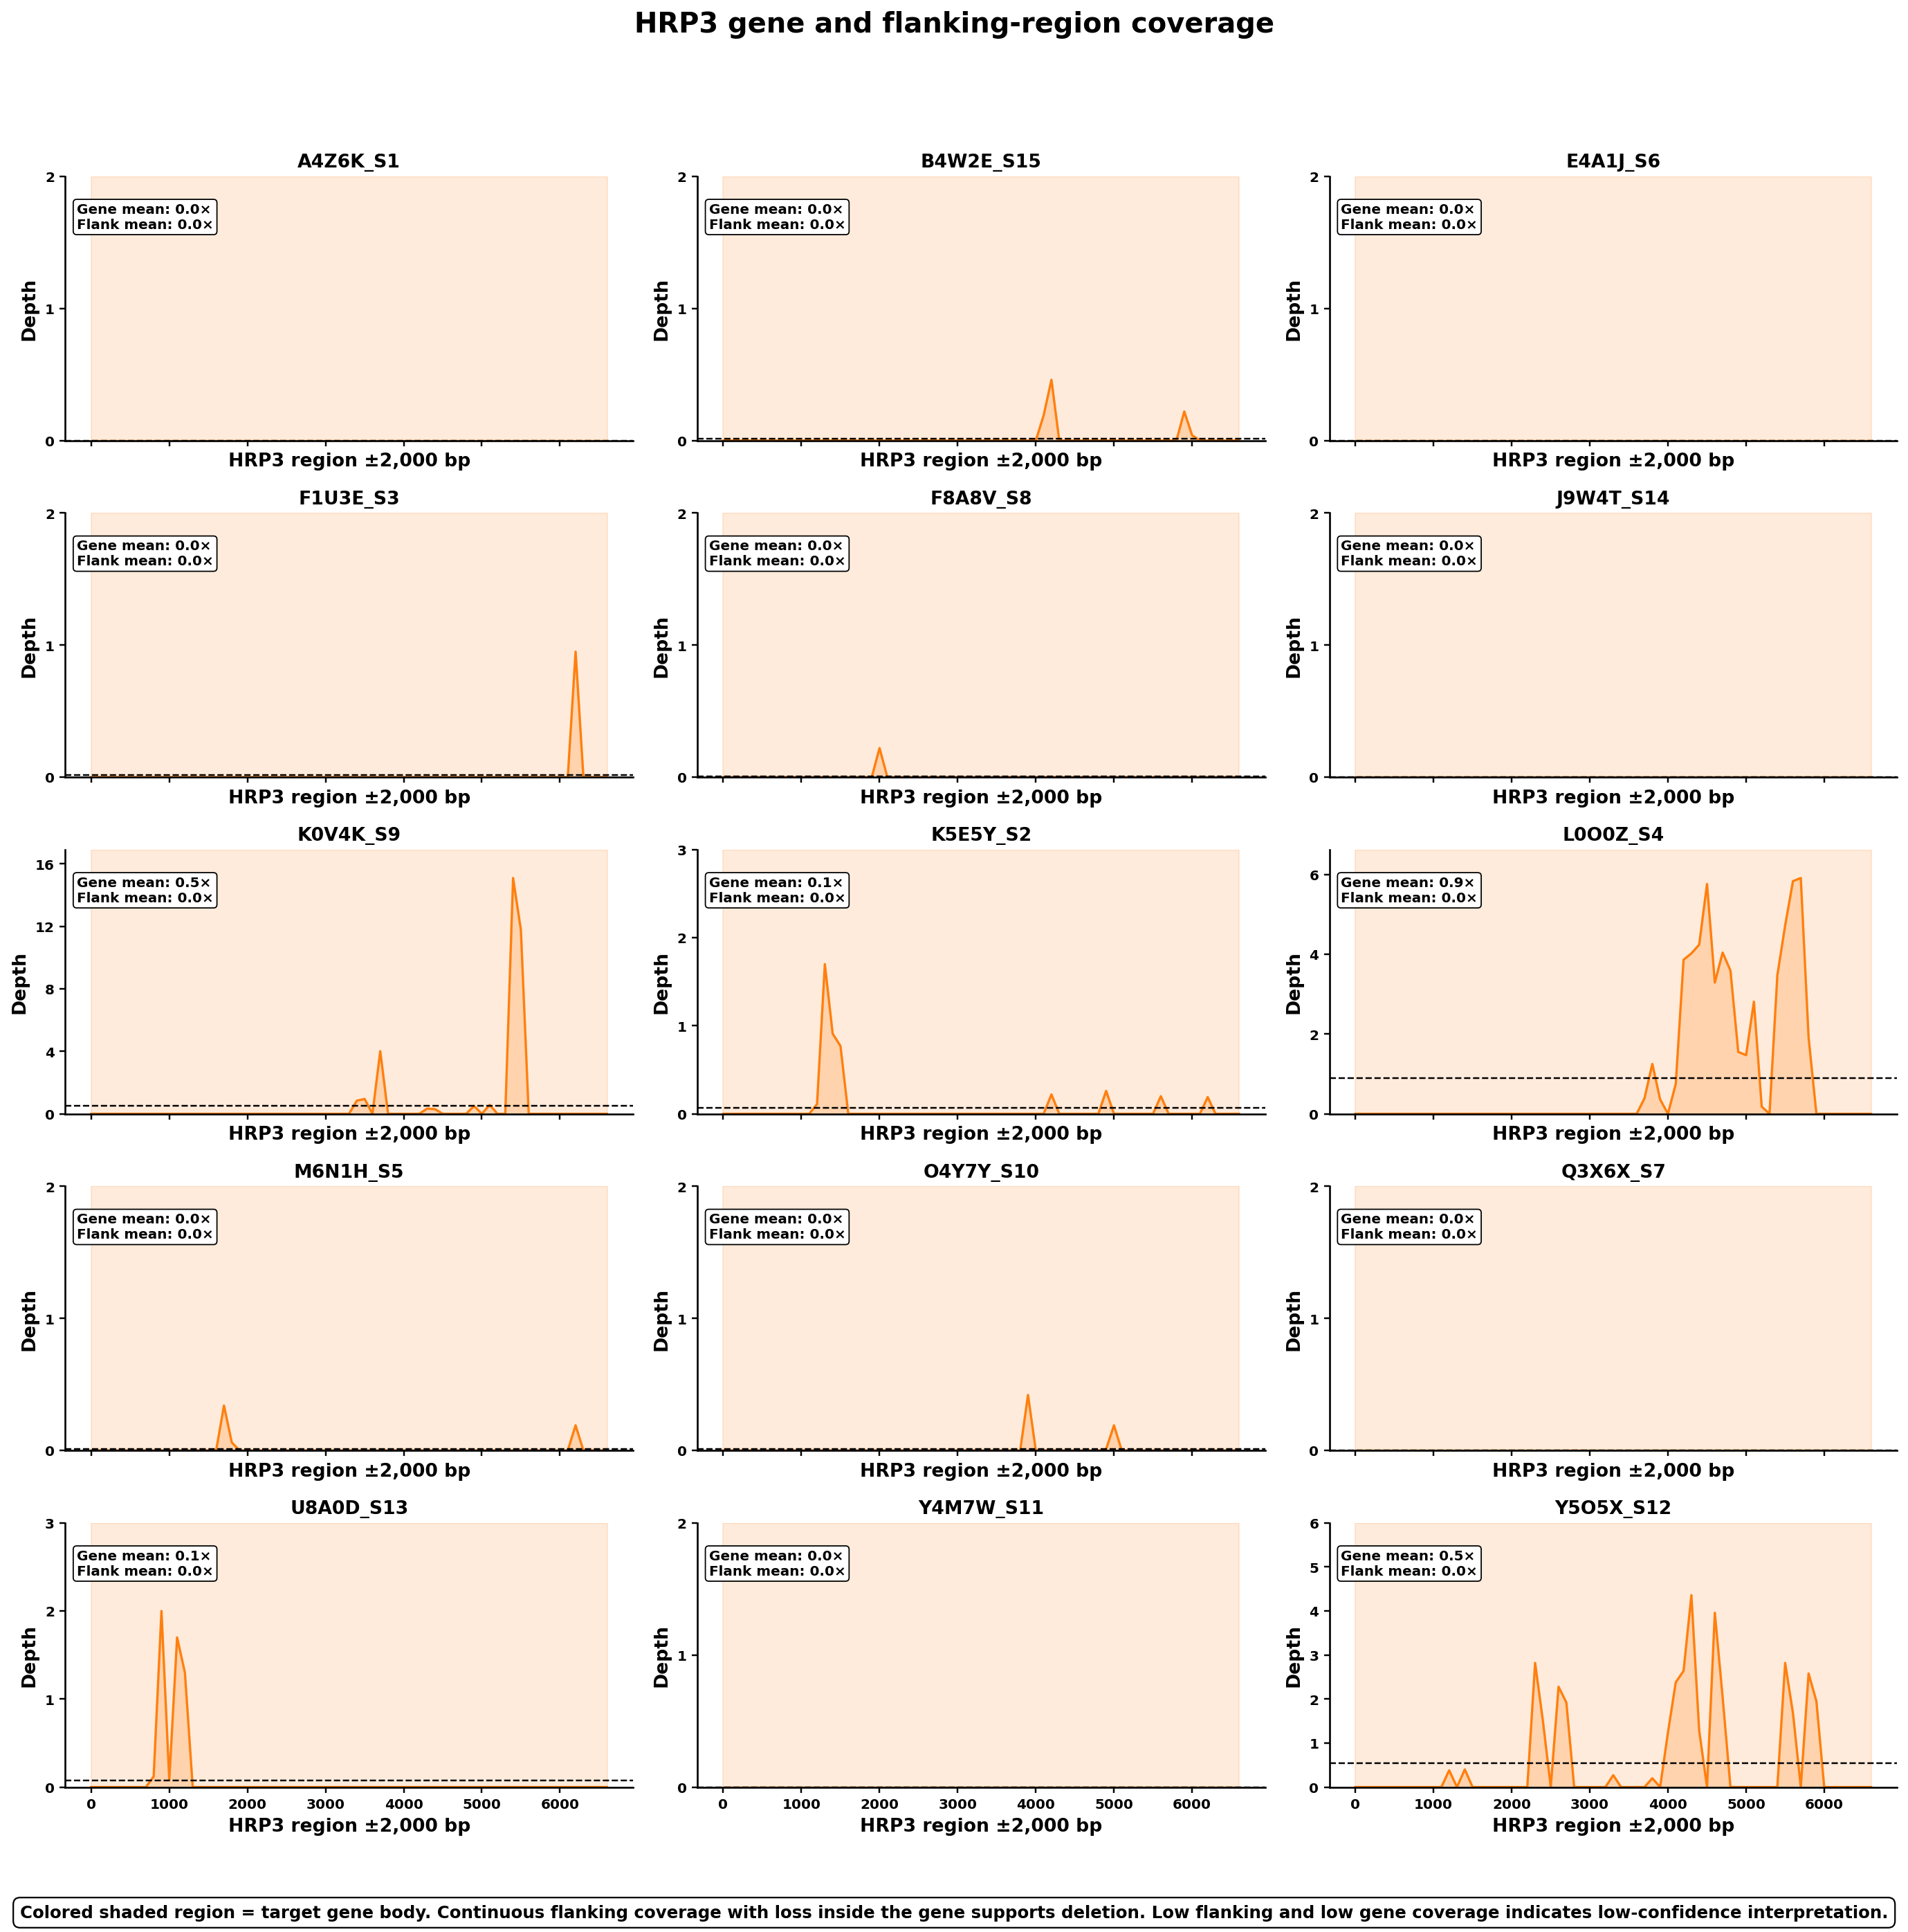

In [41]:
def plot_flanking_coverage(gene_name, flank=2000, bin_size=100):
    g = genes[gene_name]

    region_start = max(1, g["start"] - flank)
    region_end = g["end"] + flank
    gene_length = g["end"] - g["start"]

    sub = depth[
        (depth["chrom"] == g["chrom"]) &
        (depth["pos"] >= region_start) &
        (depth["pos"] <= region_end)
    ].copy()

    sub["relative_position"] = sub["pos"] - g["start"]
    sub["bin"] = (sub["relative_position"] // bin_size) * bin_size

    binned = (
        sub.groupby(["sample", "bin"])["depth"]
        .mean()
        .reset_index()
    )

    samples = sorted(binned["sample"].unique())
    n_samples = len(samples)

    ncols = 3
    nrows = math.ceil(n_samples / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.8 * ncols, 3.4 * nrows),
        sharex=True,
        sharey=False
    )

    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        sdf = binned[binned["sample"] == sample].sort_values("bin").copy()

        ax.axvspan(0, gene_length, color=g["color"], alpha=0.15)
        ax.plot(sdf["bin"], sdf["depth"], color=g["color"], linewidth=1.5)
        ax.fill_between(sdf["bin"], sdf["depth"], color=g["color"], alpha=0.22)

        gene_sub = sdf[(sdf["bin"] >= 0) & (sdf["bin"] <= gene_length)]
        flank_sub = sdf[(sdf["bin"] < 0) | (sdf["bin"] > gene_length)]

        gene_mean = gene_sub["depth"].mean() if not gene_sub.empty else 0
        flank_mean = flank_sub["depth"].mean() if not flank_sub.empty else 0
        max_depth = sdf["depth"].max() if not sdf.empty else 0

        ax.axhline(gene_mean, color="black", linestyle="--", linewidth=1.1)

        ax.text(
            0.02,
            0.90,
            f"Gene mean: {gene_mean:.1f}×\nFlank mean: {flank_mean:.1f}×",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", linewidth=0.8, boxstyle="round,pad=0.25")
        )

        ax.set_title(sample, fontsize=12, fontweight="bold")
        ax.set_xlabel(f"{gene_name} region ±{flank:,} bp", fontweight="bold")
        ax.set_ylabel("Depth", fontweight="bold")

        if max_depth <= 1:
            ax.set_ylim(0, 2)
            ax.set_yticks([0, 1, 2])
        elif max_depth <= 2:
            ax.set_ylim(0, 3)
            ax.set_yticks([0, 1, 2, 3])
        elif max_depth <= 5:
            ax.set_ylim(0, math.ceil(max_depth) + 1)
            ax.set_yticks(np.arange(0, math.ceil(max_depth) + 2, 1))
        else:
            ax.set_ylim(0, max_depth * 1.12)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

        ax.tick_params(axis="both", labelsize=9, width=1.1)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[n_samples:]:
        ax.axis("off")

    fig.suptitle(
        f"{gene_name} gene and flanking-region coverage",
        fontsize=18,
        fontweight="bold",
        y=1.02
    )

    explanation = (
        "Colored shaded region = target gene body. "
        "Continuous flanking coverage with loss inside the gene supports deletion. "
        "Low flanking and low gene coverage indicates low-confidence interpretation."
    )

    fig.text(
        0.5,
        0.005,
        explanation,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="black", linewidth=1.0, boxstyle="round,pad=0.4")
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    savefig(f"strong_05_{gene_name.lower()}_flanking_coverage_panels")
    plt.show()

plot_flanking_coverage("HRP2")
plot_flanking_coverage("HRP3")

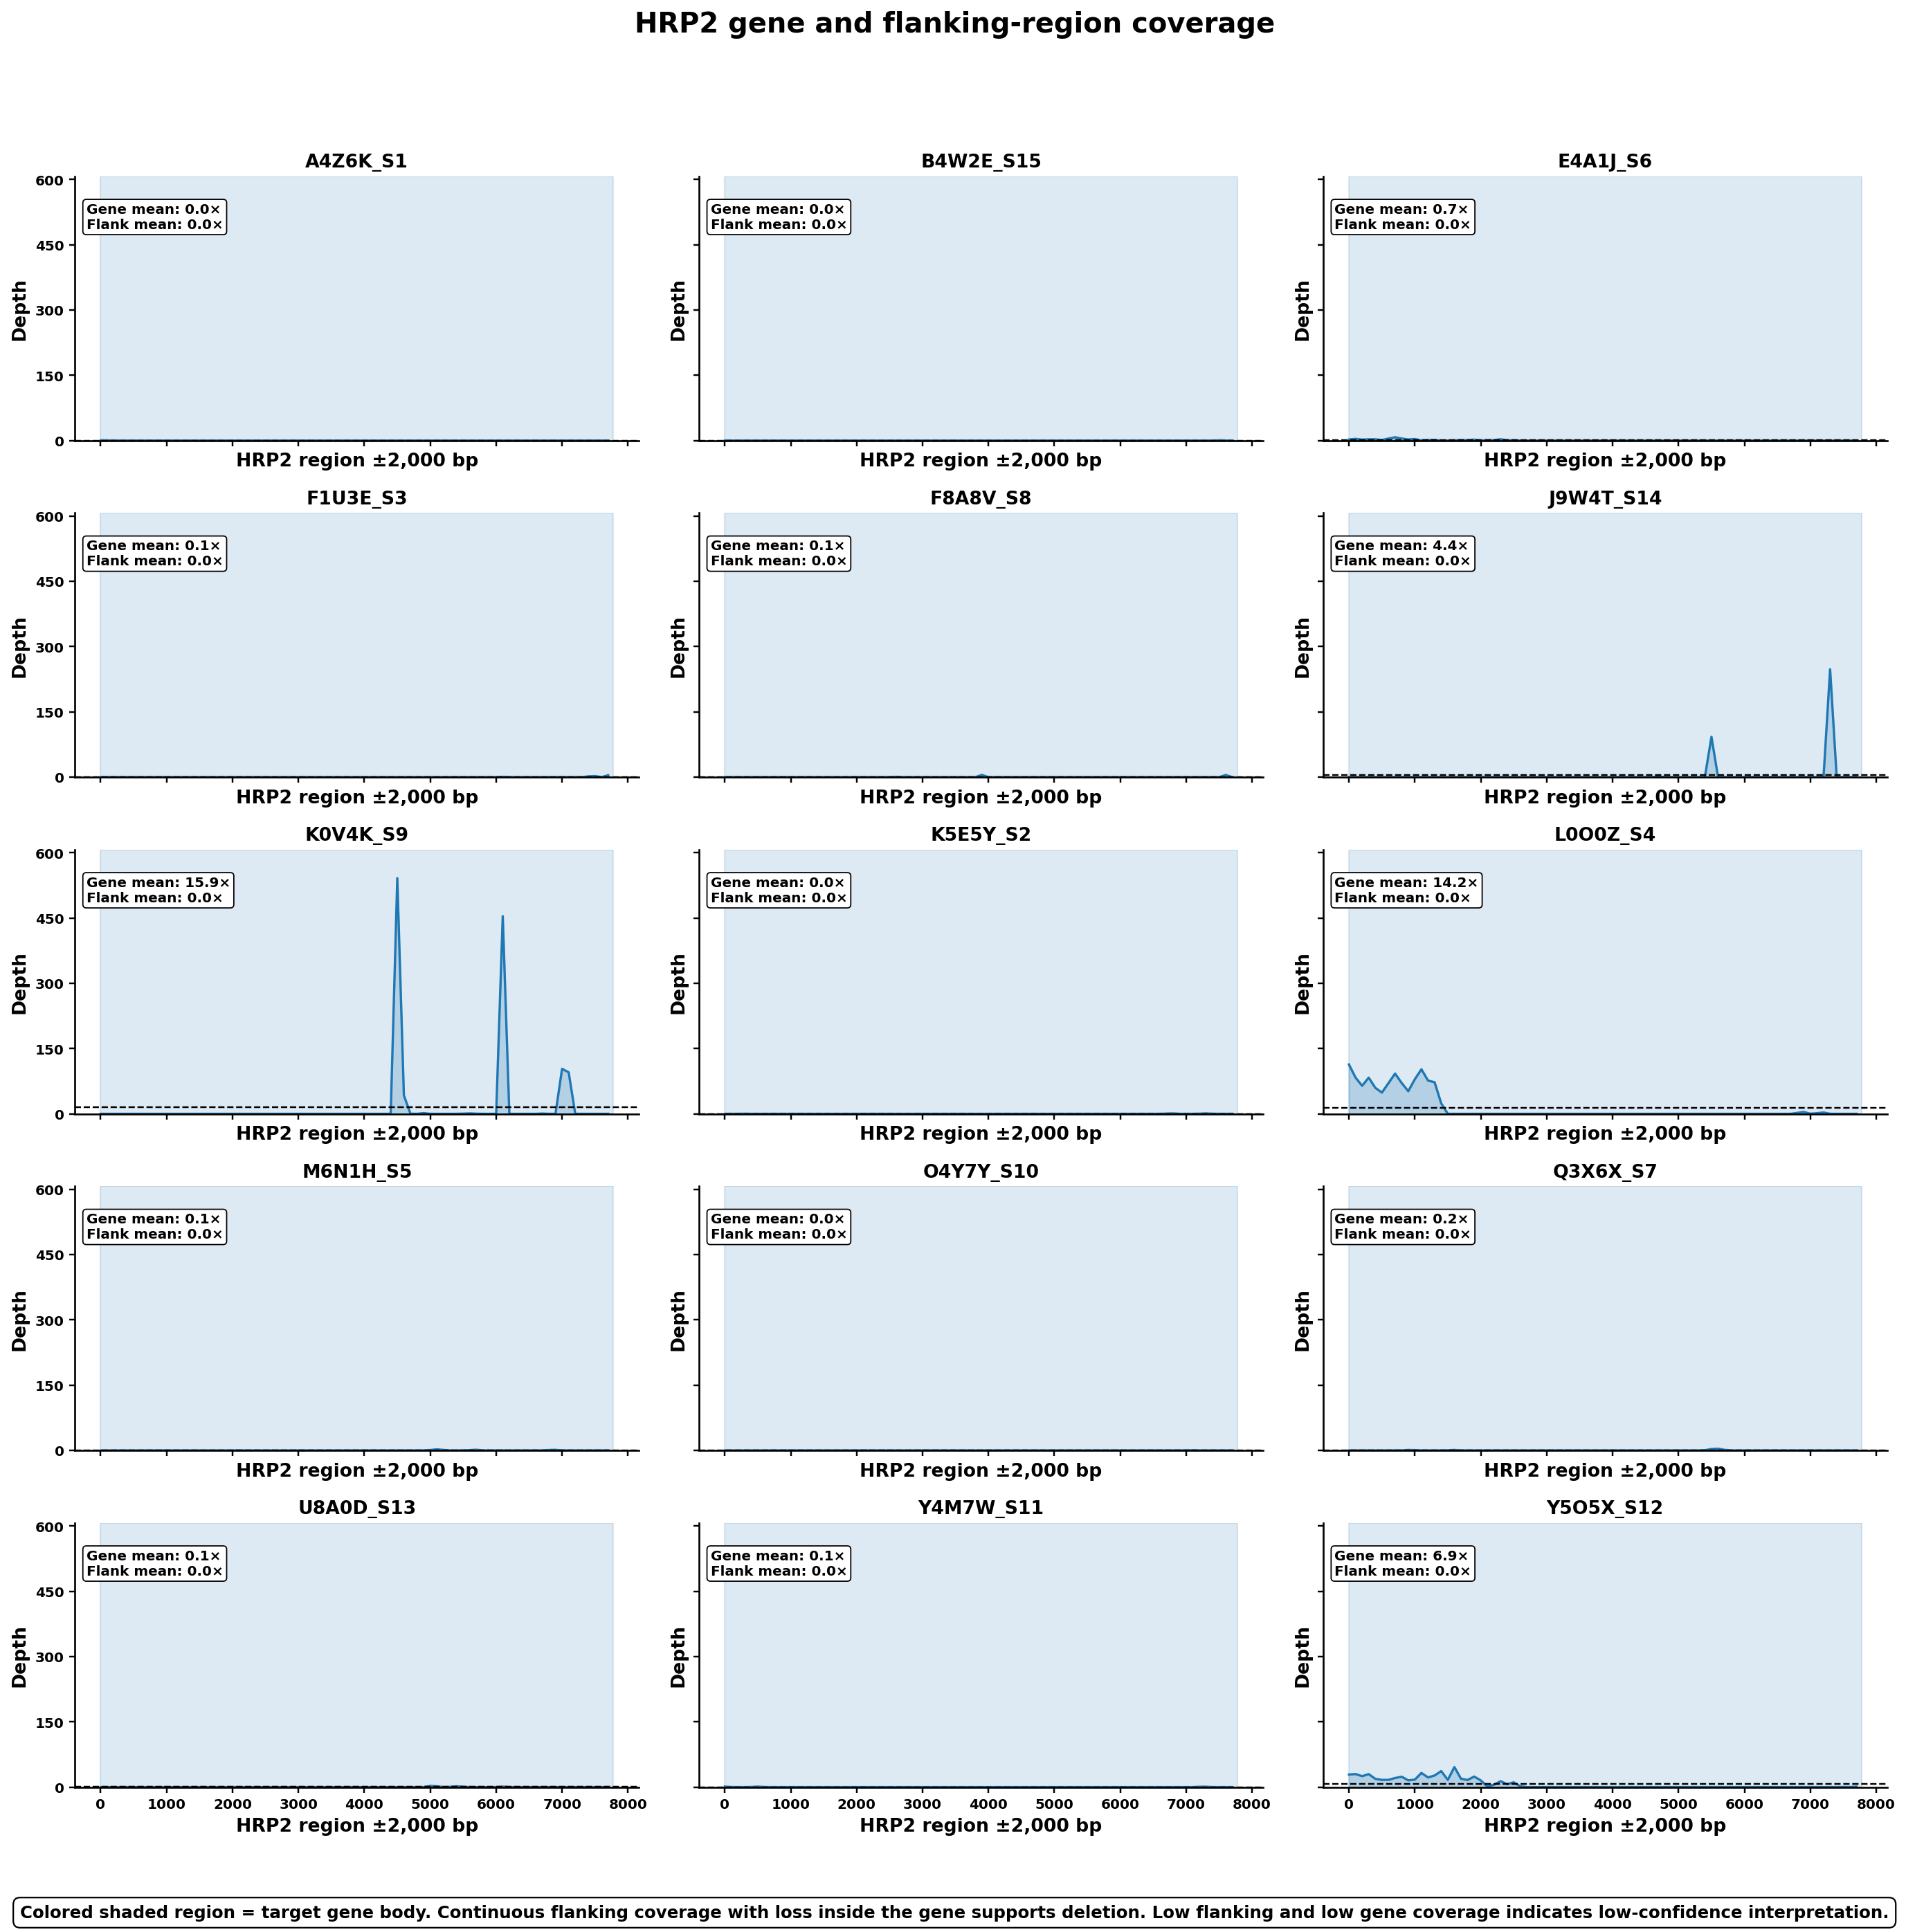

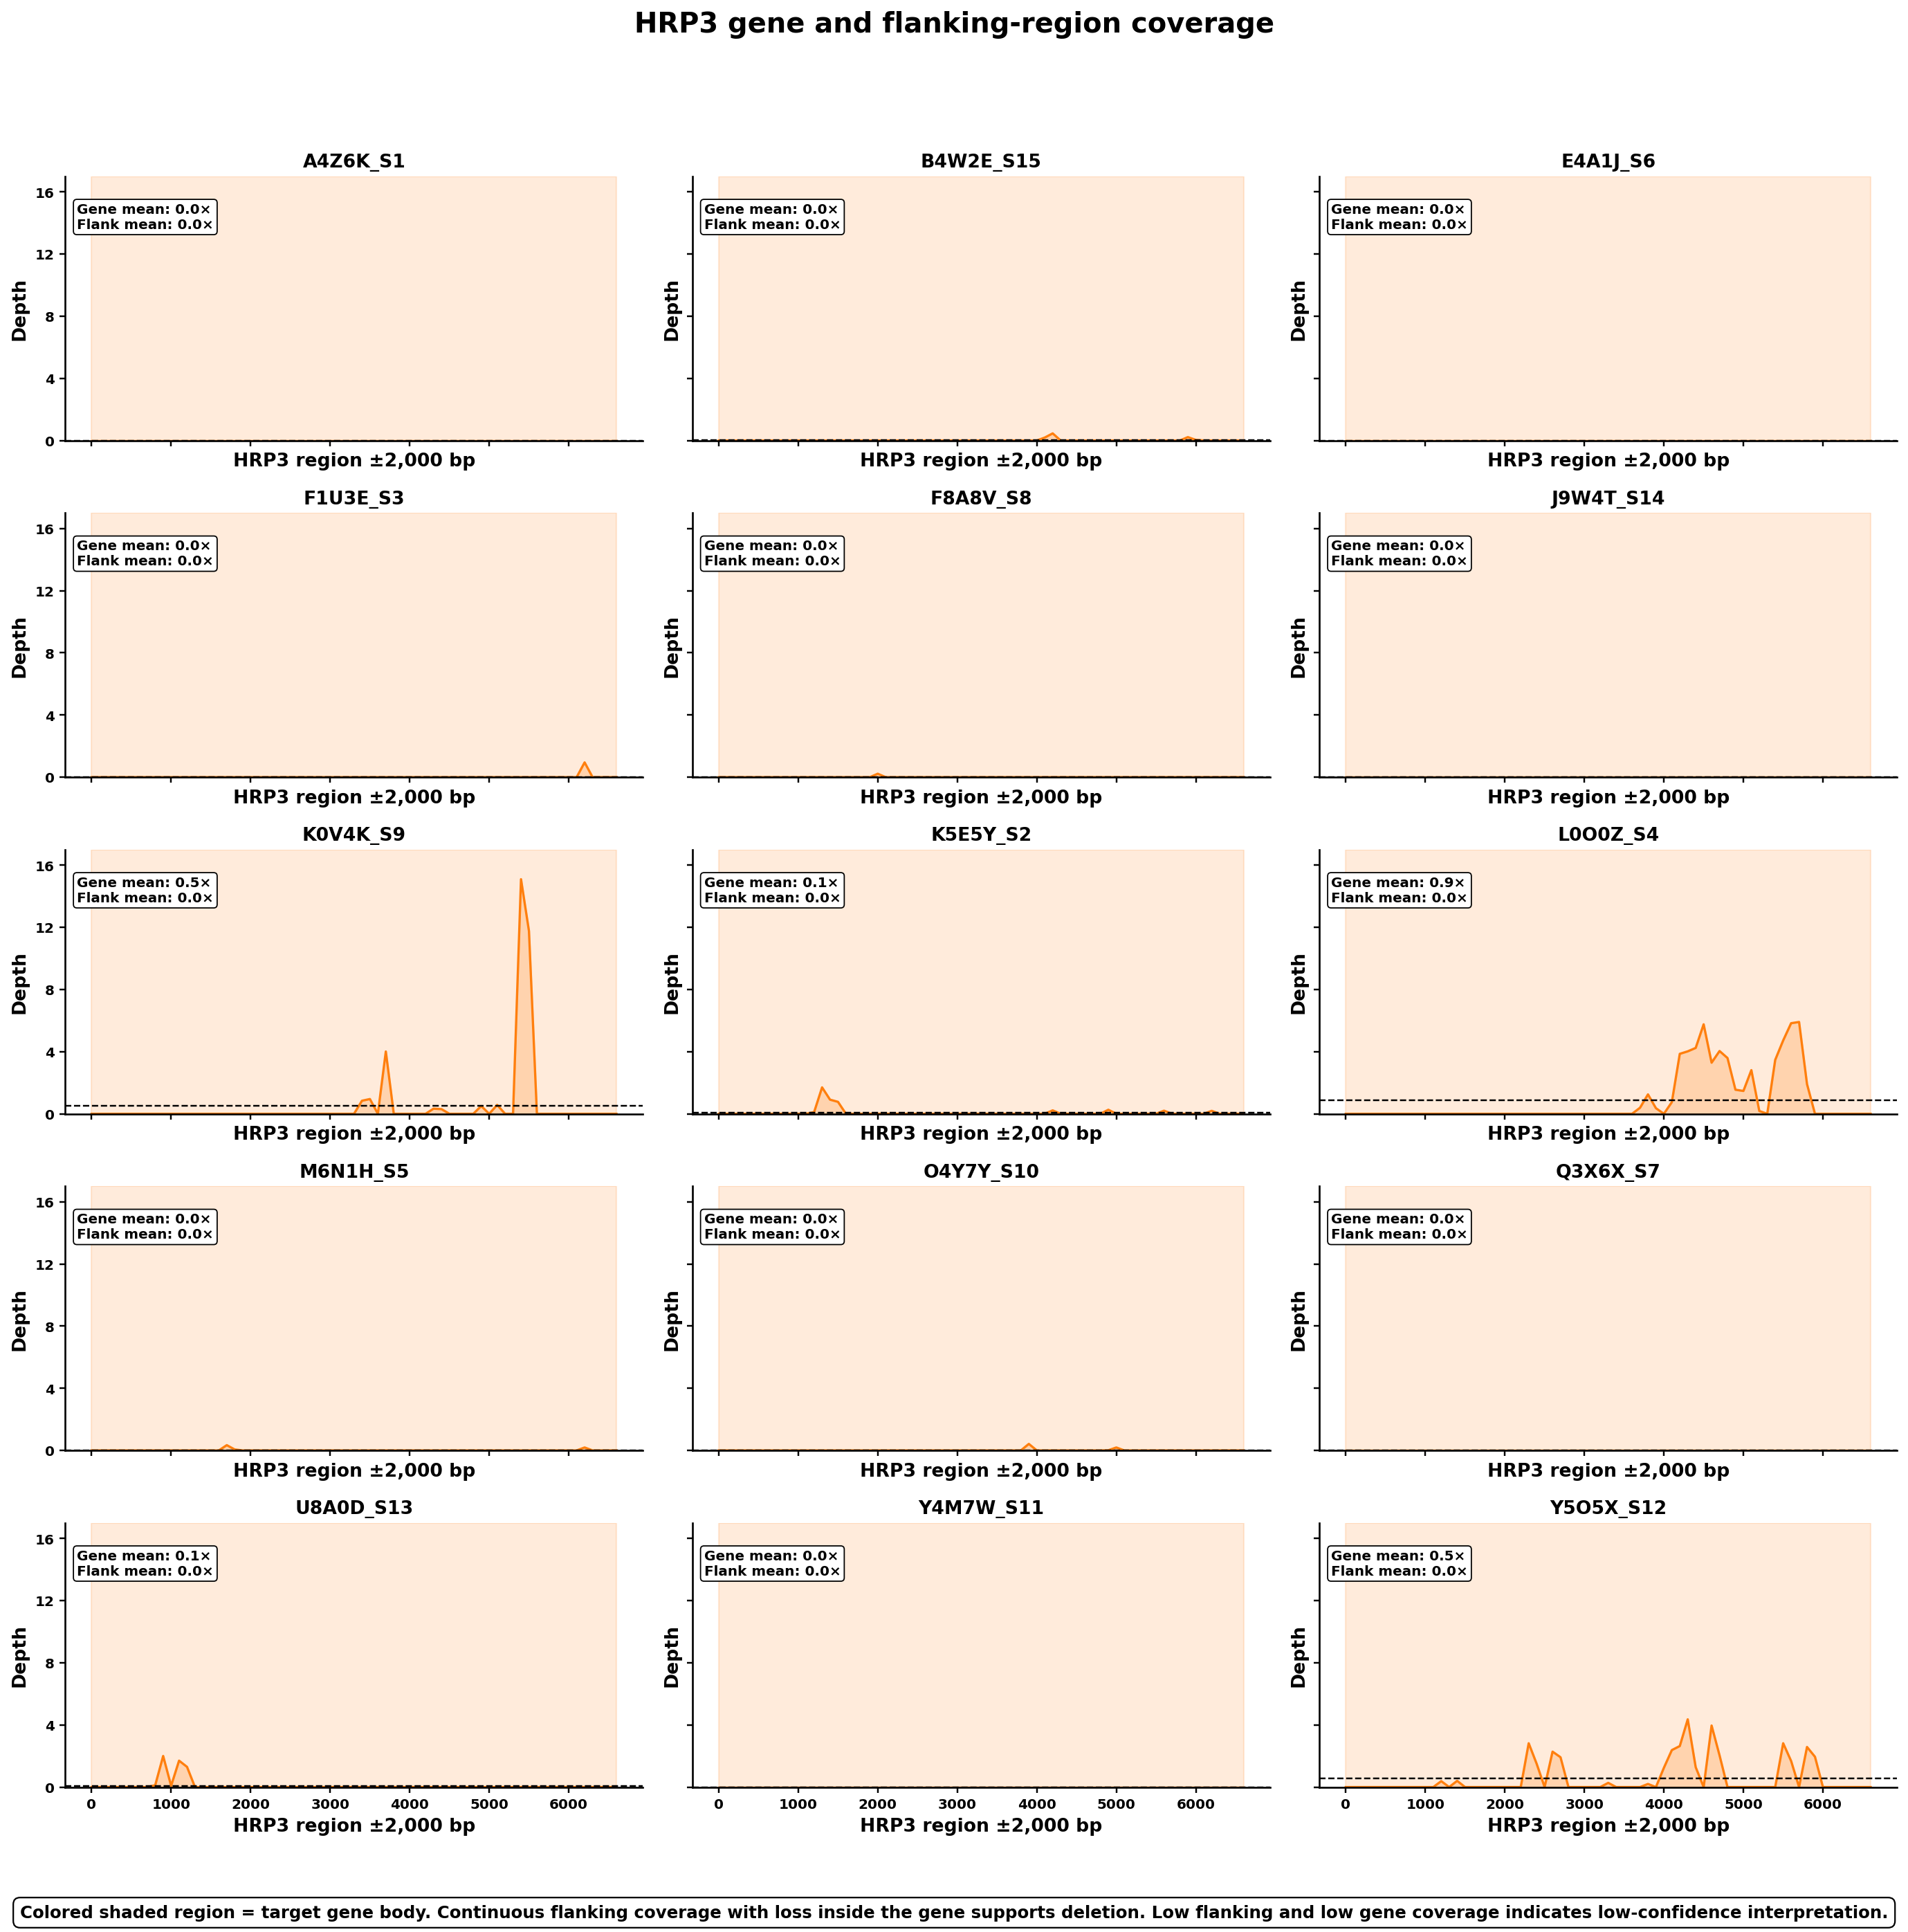

In [42]:
def plot_flanking_coverage(gene_name, flank=2000, bin_size=100):
    g = genes[gene_name]

    region_start = max(1, g["start"] - flank)
    region_end = g["end"] + flank
    gene_length = g["end"] - g["start"]

    sub = depth[
        (depth["chrom"] == g["chrom"]) &
        (depth["pos"] >= region_start) &
        (depth["pos"] <= region_end)
    ].copy()

    sub["relative_position"] = sub["pos"] - g["start"]
    sub["bin"] = (sub["relative_position"] // bin_size) * bin_size

    binned = (
        sub.groupby(["sample", "bin"])["depth"]
        .mean()
        .reset_index()
    )

    samples = sorted(binned["sample"].unique())
    n_samples = len(samples)

    ncols = 3
    nrows = math.ceil(n_samples / ncols)

    global_max = binned["depth"].max()
    if global_max <= 1:
        y_max = 2
        y_ticks = [0, 1, 2]
    elif global_max <= 2:
        y_max = 3
        y_ticks = [0, 1, 2, 3]
    elif global_max <= 5:
        y_max = math.ceil(global_max) + 1
        y_ticks = np.arange(0, y_max + 1, 1)
    else:
        y_max = math.ceil(global_max * 1.12)
        y_ticks = None

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.8 * ncols, 3.4 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        sdf = binned[binned["sample"] == sample].sort_values("bin").copy()

        ax.axvspan(0, gene_length, color=g["color"], alpha=0.15)
        ax.plot(sdf["bin"], sdf["depth"], color=g["color"], linewidth=1.5)
        ax.fill_between(sdf["bin"], sdf["depth"], color=g["color"], alpha=0.22)

        gene_sub = sdf[(sdf["bin"] >= 0) & (sdf["bin"] <= gene_length)]
        flank_sub = sdf[(sdf["bin"] < 0) | (sdf["bin"] > gene_length)]

        gene_mean = gene_sub["depth"].mean() if not gene_sub.empty else 0
        flank_mean = flank_sub["depth"].mean() if not flank_sub.empty else 0

        ax.axhline(gene_mean, color="black", linestyle="--", linewidth=1.1)

        ax.text(
            0.02,
            0.90,
            f"Gene mean: {gene_mean:.1f}×\nFlank mean: {flank_mean:.1f}×",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", linewidth=0.8, boxstyle="round,pad=0.25")
        )

        ax.set_title(sample, fontsize=12, fontweight="bold")
        ax.set_xlabel(f"{gene_name} region ±{flank:,} bp", fontweight="bold")
        ax.set_ylabel("Depth", fontweight="bold")

        ax.set_ylim(0, y_max)

        if y_ticks is not None:
            ax.set_yticks(y_ticks)
        else:
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

        ax.tick_params(axis="both", labelsize=9, width=1.1)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[n_samples:]:
        ax.axis("off")

    fig.suptitle(
        f"{gene_name} gene and flanking-region coverage",
        fontsize=18,
        fontweight="bold",
        y=1.02
    )

    explanation = (
        "Colored shaded region = target gene body. "
        "Continuous flanking coverage with loss inside the gene supports deletion. "
        "Low flanking and low gene coverage indicates low-confidence interpretation."
    )

    fig.text(
        0.5,
        0.005,
        explanation,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="black", linewidth=1.0, boxstyle="round,pad=0.4")
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    savefig(f"strong_05_{gene_name.lower()}_flanking_coverage_panels_same_y")
    plt.show()

plot_flanking_coverage("HRP2")
plot_flanking_coverage("HRP3")